# Análisis Exploratorio de Datos (EDA) — Panel EMBI × JLoss × GaR
**Fragilidad bancaria, riesgo de cola del crecimiento y spread soberano en economías emergentes**

Panel: Brasil, Chile, Colombia, México, Perú · 2010Q1–2022Q2 · frecuencia trimestral.

Este notebook produce **toda la materia prima de la sección de estadística descriptiva**:
estructura del panel, cobertura, tablas de descriptivos (global y por país), distribuciones,
series de tiempo, matriz de correlaciones, descomposición de varianza *within/between*,
persistencia, episodios de crisis y detección de atípicos. Las tablas clave se exportan a
CSV y LaTeX listas para el paper.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11

OUTDIR = Path('eda_output'); OUTDIR.mkdir(exist_ok=True)
FIGDIR = OUTDIR / 'figuras'; FIGDIR.mkdir(exist_ok=True)
def savefig(name): plt.savefig(FIGDIR / f'{name}.png', dpi=140, bbox_inches='tight')


In [2]:
# --- Carga y preparación ---
df = pd.read_csv('Panel_final.csv')
df['t'] = pd.PeriodIndex(df['quarter'], freq='Q')
df['date'] = df['t'].dt.to_timestamp()
df['year'] = df['t'].dt.year
df = df.sort_values(['country', 't']).reset_index(drop=True)

# etiquetas legibles y unidades
LABELS = {
 'EMBI_bps':'Spread EMBI (pb)', 'JLoss':'Fragilidad bancaria JLoss',
 'GaR':'Growth-at-Risk (q05)', 'GaR_st':'GaR skew-t', 'ES':'Expected Shortfall',
 'prob_neg':'Prob. crecim. negativo', 'skew':'Asimetría', 'std':'Desv. condicional',
 'VIX':'VIX (estandarizado)', 'g_GDP':'Crecimiento PIB (estand.)',
 'debt_gdp':'Deuda/PIB (%)', 'fisc_bal':'Balance fiscal/PIB (%)',
 'res_gdp':'Reservas/PIB (%)', 'ca_gdp':'Cuenta corriente/PIB (%)',
 'infl_yoy':'Inflación YoY (%)', 'reer':'REER (índice)', 'JLoss_x_GaR':'JLoss × GaR'}

CORE   = ['EMBI_bps','JLoss','GaR','ES','prob_neg']
CTRLS  = ['debt_gdp','fisc_bal','res_gdp','ca_gdp','infl_yoy','reer','VIX']
ALLV   = CORE + ['GaR_st','skew','std','g_GDP'] + CTRLS
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (248, 22)


,country,quarter,EMBI_bps,JLoss,GaR,GaR_st,prob_neg,ES,skew,std,...,debt_gdp,fisc_bal,res_gdp,ca_gdp,infl_yoy,reer,JLoss_x_GaR,t,date,year
0,brazil,2010Q1,203.3947,6.3861,0.0676,0.0676,0.0000,0.0586,0.3047,0.0126,...,61.3188,-2.4818,13.3148,-3.3843,5.0011,160.7400,0.4318,2010Q1,2010-01-01,2010
1,brazil,2010Q2,212.2581,6.6256,0.0138,0.0133,0.0000,0.0134,-0.2463,0.0169,...,61.3188,-2.4818,13.0645,-3.9259,5.0387,166.7200,0.0916,2010Q2,2010-04-01,2010
2,brazil,2010Q3,211.0862,2.4680,0.0500,0.0502,0.0000,0.0265,0.3570,0.0106,...,60.8245,-2.5406,13.1751,-3.7431,5.4382,168.7467,0.1233,2010Q3,2010-07-01,2010
3,brazil,2010Q4,179.1736,2.4714,0.0444,0.0446,0.0000,0.0325,0.7348,0.0119,...,60.3302,-2.5994,13.2764,-3.5603,5.8376,170.9600,0.1097,2010Q4,2010-10-01,2010
4,brazil,2011Q1,173.2938,3.5675,0.0310,0.0313,0.0000,0.0259,0.2379,0.0124,...,59.8359,-2.6582,13.3694,-3.3774,6.2370,174.6033,0.1104,2011Q1,2011-01-01,2011


## 1. Estructura del panel y cobertura

In [3]:
n_country = df['country'].nunique()
n_periods = df['t'].nunique()
print(f'Países: {n_country} | Trimestres distintos: {n_periods} | Observaciones: {len(df)}')
print(f'Panel balanceado teórico: {n_country*n_periods} | balance real: {len(df)/(n_country*n_periods):.1%}')

cov = (df.groupby('country')
         .agg(N=('quarter','size'), inicio=('quarter','min'), fin=('quarter','max'))
         .reset_index())
cov

Países: 5 | Trimestres distintos: 50 | Observaciones: 248
Panel balanceado teórico: 250 | balance real: 99.2%


,country,N,inicio,fin
0,brazil,50,2010Q1,2022Q2
1,chile,48,2010Q1,2021Q4
2,colombia,50,2010Q1,2022Q2
3,mexico,50,2010Q1,2022Q2
4,peru,50,2010Q1,2022Q2


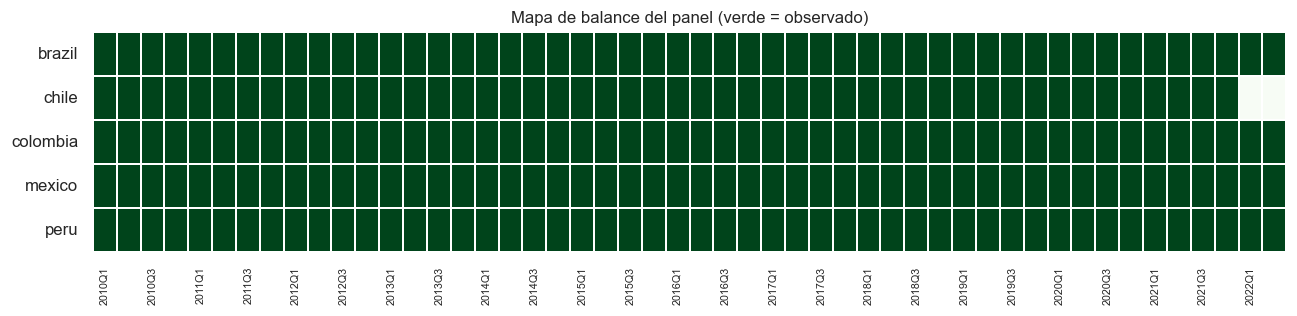

In [4]:
# Mapa de balance del panel (país x trimestre)
piv = df.assign(x=1).pivot_table(index='country', columns='t', values='x', fill_value=0)
fig, ax = plt.subplots(figsize=(14,2.6))
sns.heatmap(piv, cbar=False, cmap='Greens', linewidths=.3, linecolor='white', ax=ax)
ax.set_title('Mapa de balance del panel (verde = observado)')
ax.set_xlabel(''); ax.set_ylabel('')
step = max(1, piv.shape[1]//20)
ax.set_xticks(np.arange(0, piv.shape[1], step)+0.5)
ax.set_xticklabels([str(p) for p in piv.columns[::step]], rotation=90, fontsize=7)
savefig('01_balance_panel'); plt.show()

## 2. Datos faltantes

In [5]:
miss = (df[ALLV].isna().mean()*100).round(1).sort_values(ascending=False)
miss = miss[miss>0]
if len(miss):
    print('Columnas con faltantes (%):'); print(miss.to_string())
    print('\nDetalle por país de las columnas con huecos:')
    for col in miss.index:
        sub = df[df[col].isna()].groupby('country')['quarter'].agg(['size','min','max'])
        print(f'\n[{col}]'); print(sub.to_string())
else:
    print('Sin faltantes.')
# Nota: debt_gdp suele faltar para Chile (WDI GC.* sin cobertura) -> usar IMF WEO para versión final.

Sin faltantes.


## 3. Estadística descriptiva (tabla principal del paper)

Tabla global con media, desviación, mínimo, cuartiles, máximo y N. Se exporta a CSV y LaTeX.

In [6]:
def describe_block(d, cols):
    s = d[cols].describe(percentiles=[.25,.5,.75]).T
    s = s[['count','mean','std','min','25%','50%','75%','max']]
    s.columns = ['N','Media','Desv.','Mín','p25','Mediana','p75','Máx']
    s.index = [LABELS.get(c,c) for c in cols]
    return s.round(3)

desc = describe_block(df, CORE + ['skew','std','g_GDP'] + CTRLS)
desc.to_csv(OUTDIR/'tabla_descriptiva_global.csv')
# LaTeX (booktabs) listo para el paper
with open(OUTDIR/'tabla_descriptiva_global.tex','w') as f:
    f.write(desc.to_latex(escape=True, column_format='lrrrrrrrr',
            caption='Estadística descriptiva del panel (2010Q1–2022Q2).',
            label='tab:desc'))
desc

,N,Media,Desv.,Mín,p25,Mediana,p75,Máx
Spread EMBI (pb),248.0000,213.1180,78.4110,114.8830,156.3440,192.3700,253.1290,590.5710
Fragilidad bancaria JLoss,248.0000,6.0480,8.7860,1.5530,2.1850,2.3850,4.6420,46.8330
Growth-at-Risk (q05),248.0000,0.0030,0.0410,-0.2180,-0.0110,0.0040,0.0230,0.1010
Expected Shortfall,248.0000,-0.0080,0.0520,-0.3010,-0.0180,-0.0010,0.0150,0.0990
Prob. crecim. negativo,248.0000,0.1500,0.2750,0.0000,0.0000,0.0310,0.1320,1.0000
Asimetría,248.0000,0.0850,0.3020,-0.7350,-0.0790,0.0550,0.2720,0.8080
Desv. condicional,248.0000,0.0130,0.0050,0.0060,0.0100,0.0110,0.0130,0.0360
Crecimiento PIB (estand.),248.0000,-0.1080,1.1670,-5.3220,-0.4940,-0.0690,0.3250,5.1750
Deuda/PIB (%),248.0000,46.0000,23.8140,6.5040,24.4560,41.3270,65.3750,98.7100
Balance fiscal/PIB (%),248.0000,-3.2080,2.6630,-12.4360,-4.5030,-2.7250,-1.8610,2.7660


In [7]:
# Descriptivos por país (media y desviación) para variables centrales
by_country = (df.groupby('country')[CORE]
                .agg(['mean','std']).round(3))
by_country.columns = [f'{LABELS.get(v,v)} ({s})' for v,s in by_country.columns]
by_country.to_csv(OUTDIR/'tabla_descriptiva_por_pais.csv')
by_country.T

country,brazil,chile,colombia,mexico,peru
Spread EMBI (pb) (mean),263.4820,153.2200,210.1940,268.2120,168.0850
Spread EMBI (pb) (std),74.3180,32.1180,61.1910,92.2910,30.6520
Fragilidad bancaria JLoss (mean),17.5330,2.7060,4.7240,2.7720,2.3720
Fragilidad bancaria JLoss (std),14.1370,1.6620,3.6080,1.1210,0.5190
Growth-at-Risk (q05) (mean),-0.0120,0.0060,0.0080,-0.0100,0.0210
Growth-at-Risk (q05) (std),0.0360,0.0380,0.0460,0.0380,0.0380
Expected Shortfall (mean),-0.0220,-0.0030,-0.0020,-0.0210,0.0100
Expected Shortfall (std),0.0450,0.0500,0.0600,0.0500,0.0490
Prob. crecim. negativo (mean),0.2800,0.1170,0.1020,0.1920,0.0570
Prob. crecim. negativo (std),0.3500,0.2500,0.2380,0.2740,0.1880


## 4. Distribuciones univariadas

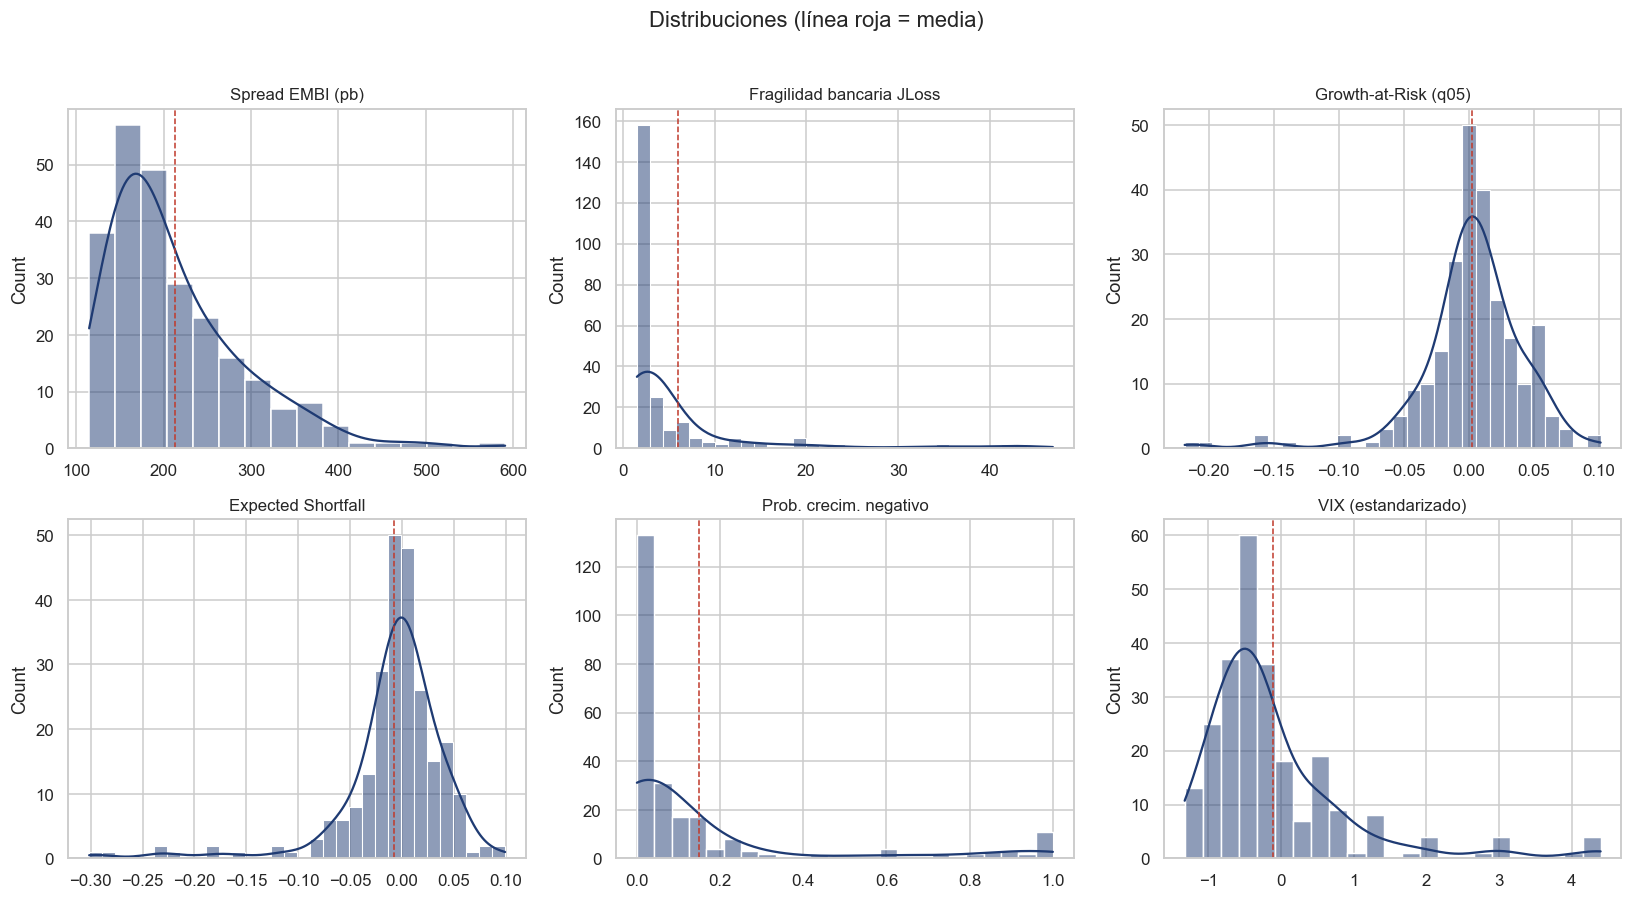

                           Asimetría  Curtosis
Spread EMBI (pb)              1.5000    2.8900
Fragilidad bancaria JLoss     3.0300    8.8400
Growth-at-Risk (q05)         -1.7500    7.3600
Expected Shortfall           -2.5700   10.2900
Prob. crecim. negativo        2.1600    3.3700
VIX (estandarizado)           2.3400    6.5800


In [8]:
vars_dist = ['EMBI_bps','JLoss','GaR','ES','prob_neg','VIX']
fig, axes = plt.subplots(2,3, figsize=(15,8)); axes=axes.ravel()
for i,v in enumerate(vars_dist):
    sns.histplot(df[v], kde=True, ax=axes[i], color='#1f3b73')
    axes[i].set_title(LABELS.get(v,v)); axes[i].set_xlabel('')
    axes[i].axvline(df[v].mean(), color='#c0392b', ls='--', lw=1)
fig.suptitle('Distribuciones (línea roja = media)', y=1.02)
plt.tight_layout(); savefig('04_distribuciones'); plt.show()

# Asimetría y curtosis (justifican transformaciones / colas pesadas)
from scipy.stats import skew, kurtosis
shape = pd.DataFrame({
    'Asimetría':[skew(df[v].dropna()) for v in vars_dist],
    'Curtosis' :[kurtosis(df[v].dropna()) for v in vars_dist]}, index=[LABELS[v] for v in vars_dist]).round(2)
print(shape.to_string())

C:\Users\HOME\AppData\Local\Temp\ipykernel_30968\30169988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='country', y=v, ax=ax, palette='Blues')
C:\Users\HOME\AppData\Local\Temp\ipykernel_30968\30169988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='country', y=v, ax=ax, palette='Blues')
C:\Users\HOME\AppData\Local\Temp\ipykernel_30968\30169988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='country', y=v, ax=ax, palette='Blues')


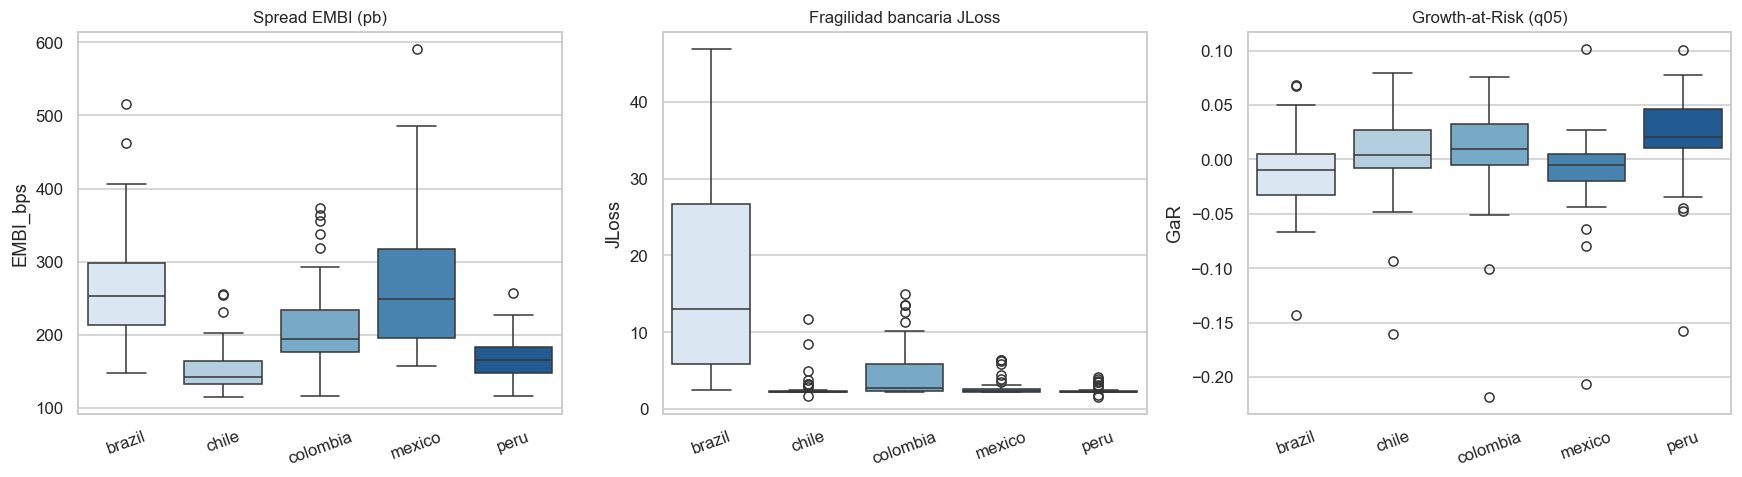

In [9]:
# Boxplots por país (heterogeneidad entre economías)
fig, axes = plt.subplots(1,3, figsize=(16,4.5))
for ax,v in zip(axes, ['EMBI_bps','JLoss','GaR']):
    sns.boxplot(data=df, x='country', y=v, ax=ax, palette='Blues')
    ax.set_title(LABELS[v]); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); savefig('04b_boxplots_pais'); plt.show()

## 5. Series de tiempo por país

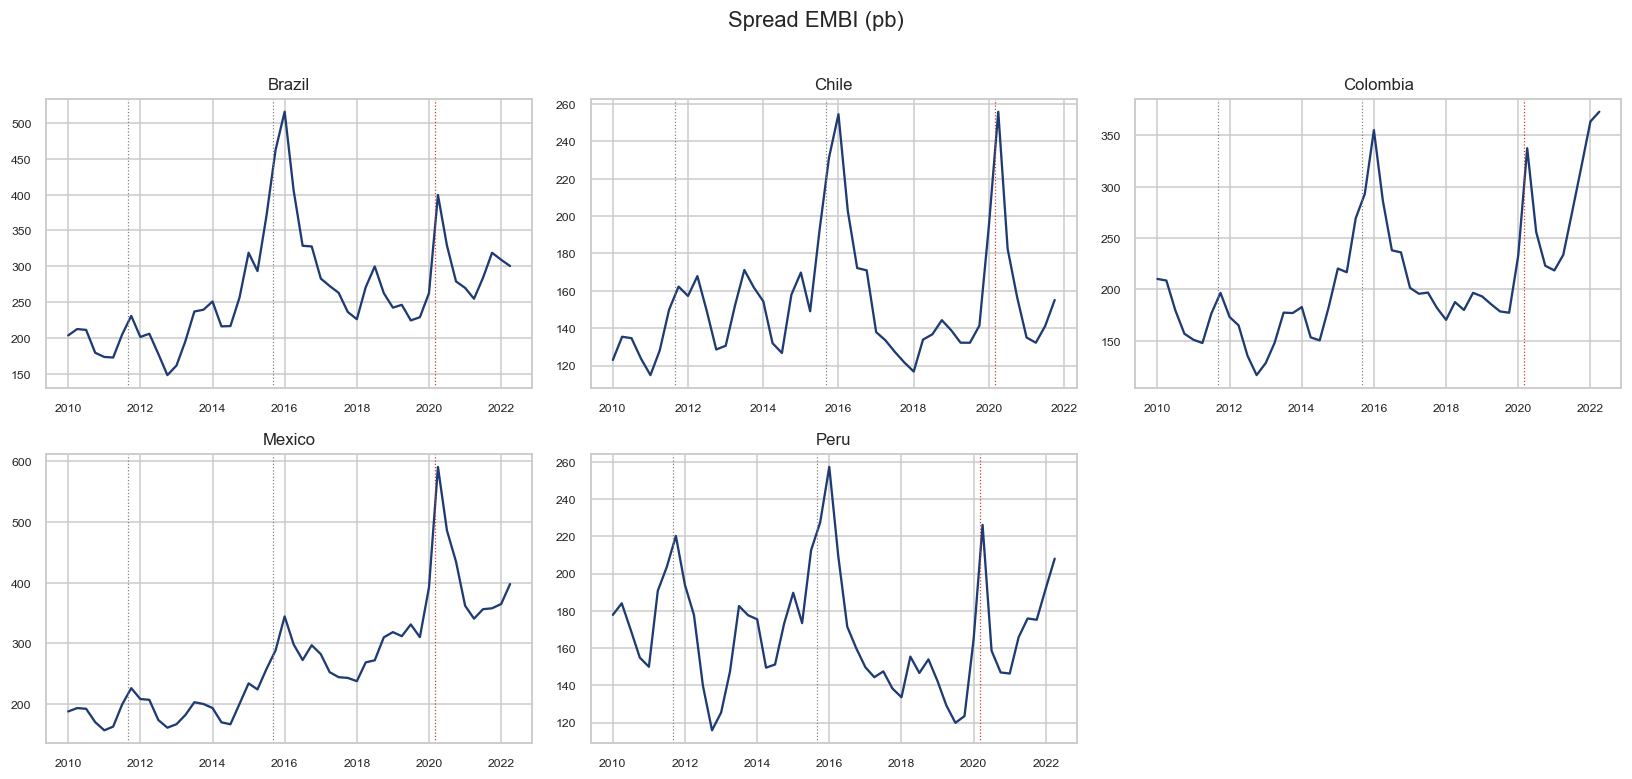

In [10]:
def panel_timeseries(var, color='#1f3b73', logy=False):
    fig, axes = plt.subplots(2,3, figsize=(15,7)); axes=axes.ravel()
    for i,(c,g) in enumerate(df.groupby('country')):
        g=g.sort_values('date')
        axes[i].plot(g['date'], g[var], color=color, lw=1.5)
        axes[i].set_title(c.capitalize()); axes[i].tick_params(labelsize=8)
        if logy: axes[i].set_yscale('log')
        for yr,lab,col in [('2011-09','UE','grey'),('2015-09','Commodity','grey'),('2020-03','COVID','#c0392b')]:
            axes[i].axvline(pd.Timestamp(yr), color=col, ls=':', lw=.8)
    axes[-1].axis('off')
    fig.suptitle(LABELS.get(var,var), y=1.01); plt.tight_layout()
panel_timeseries('EMBI_bps'); savefig('05_ts_embi'); plt.show()

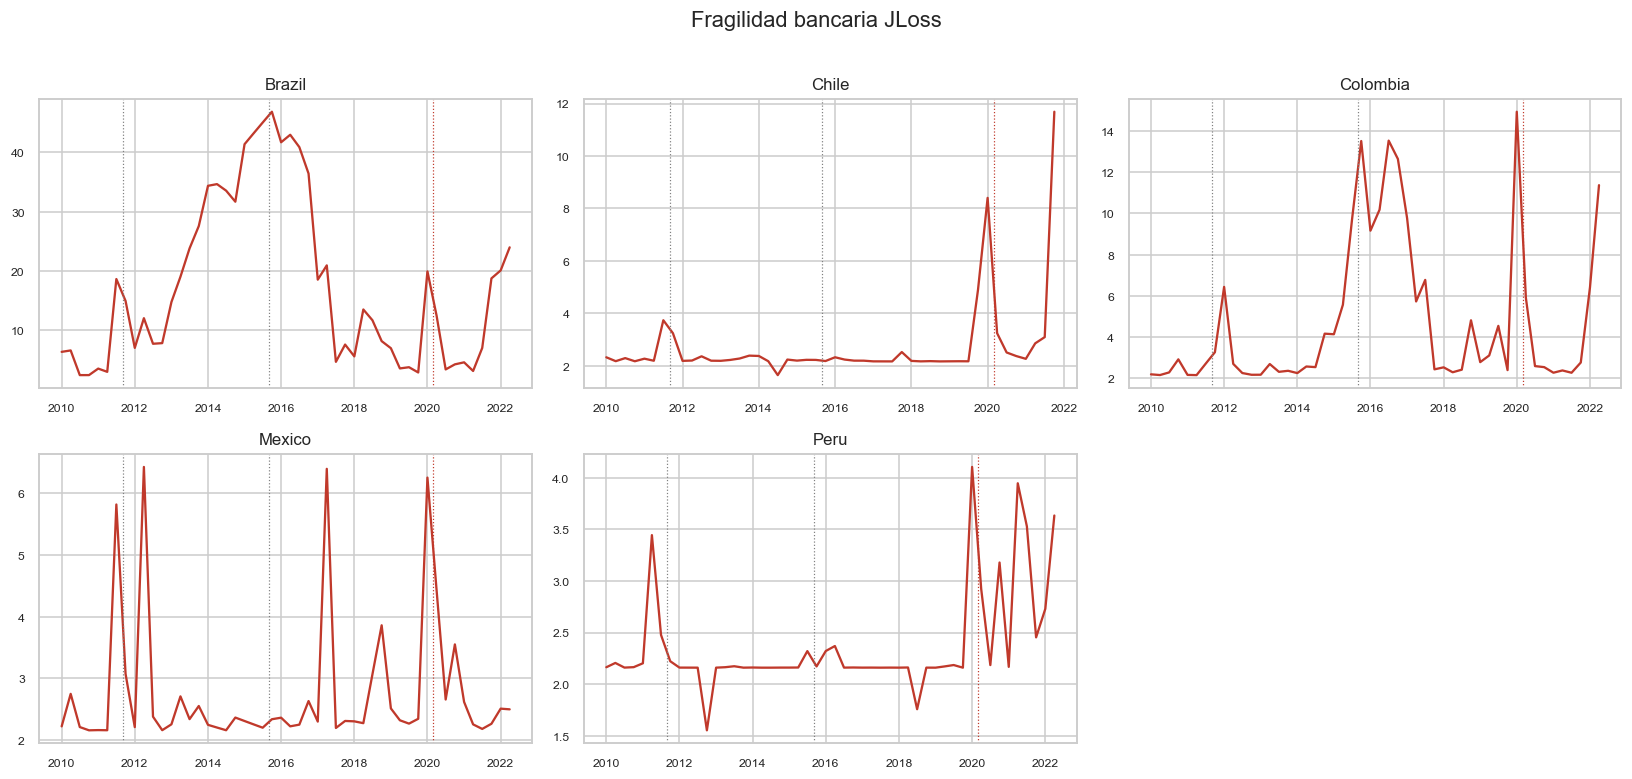

In [11]:
panel_timeseries('JLoss', color='#c0392b'); savefig('05_ts_jloss'); plt.show()

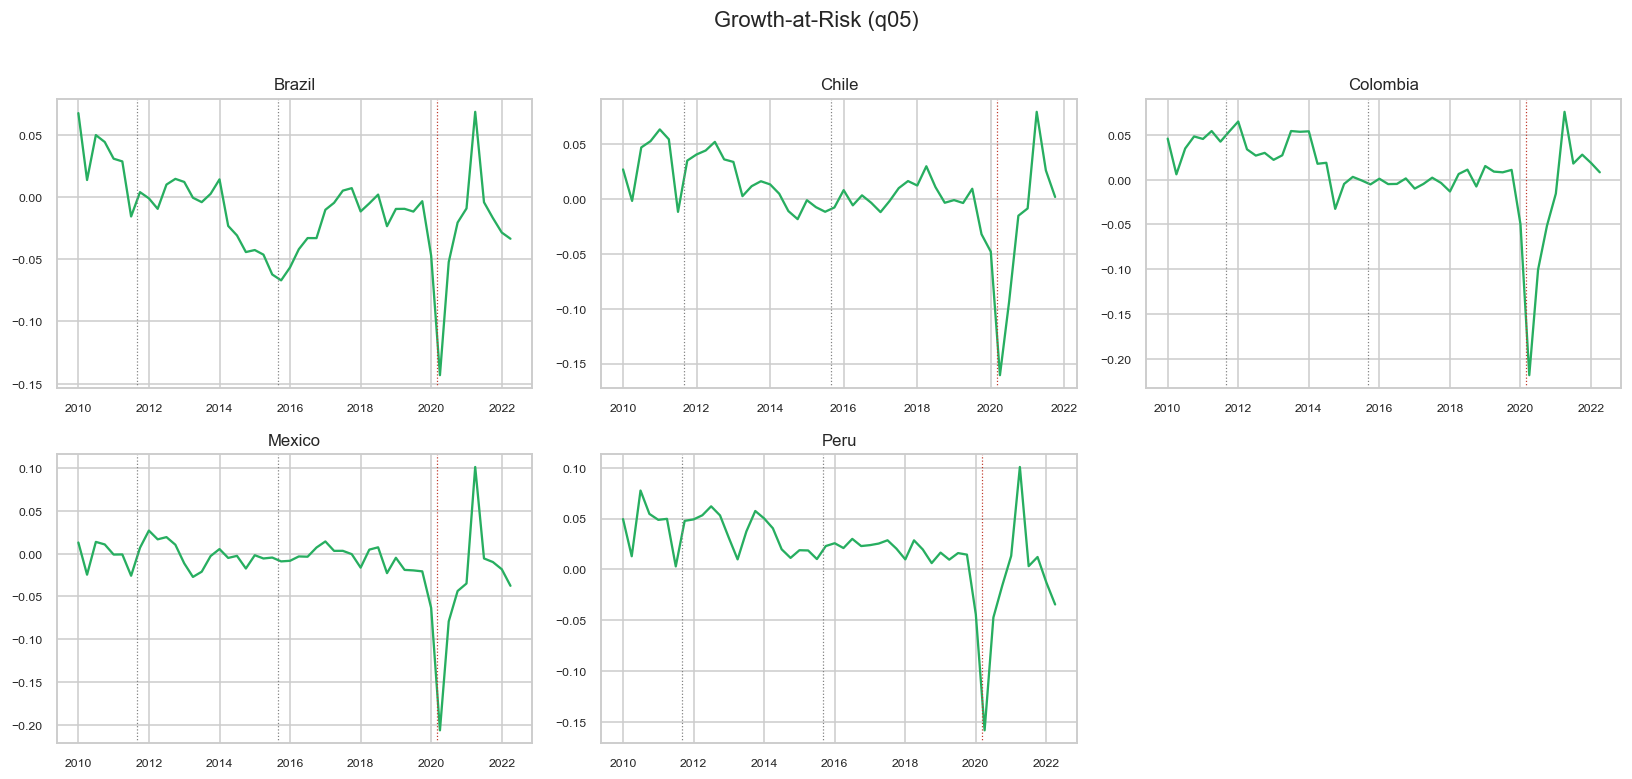

In [12]:
panel_timeseries('GaR', color='#27ae60'); savefig('05_ts_gar'); plt.show()

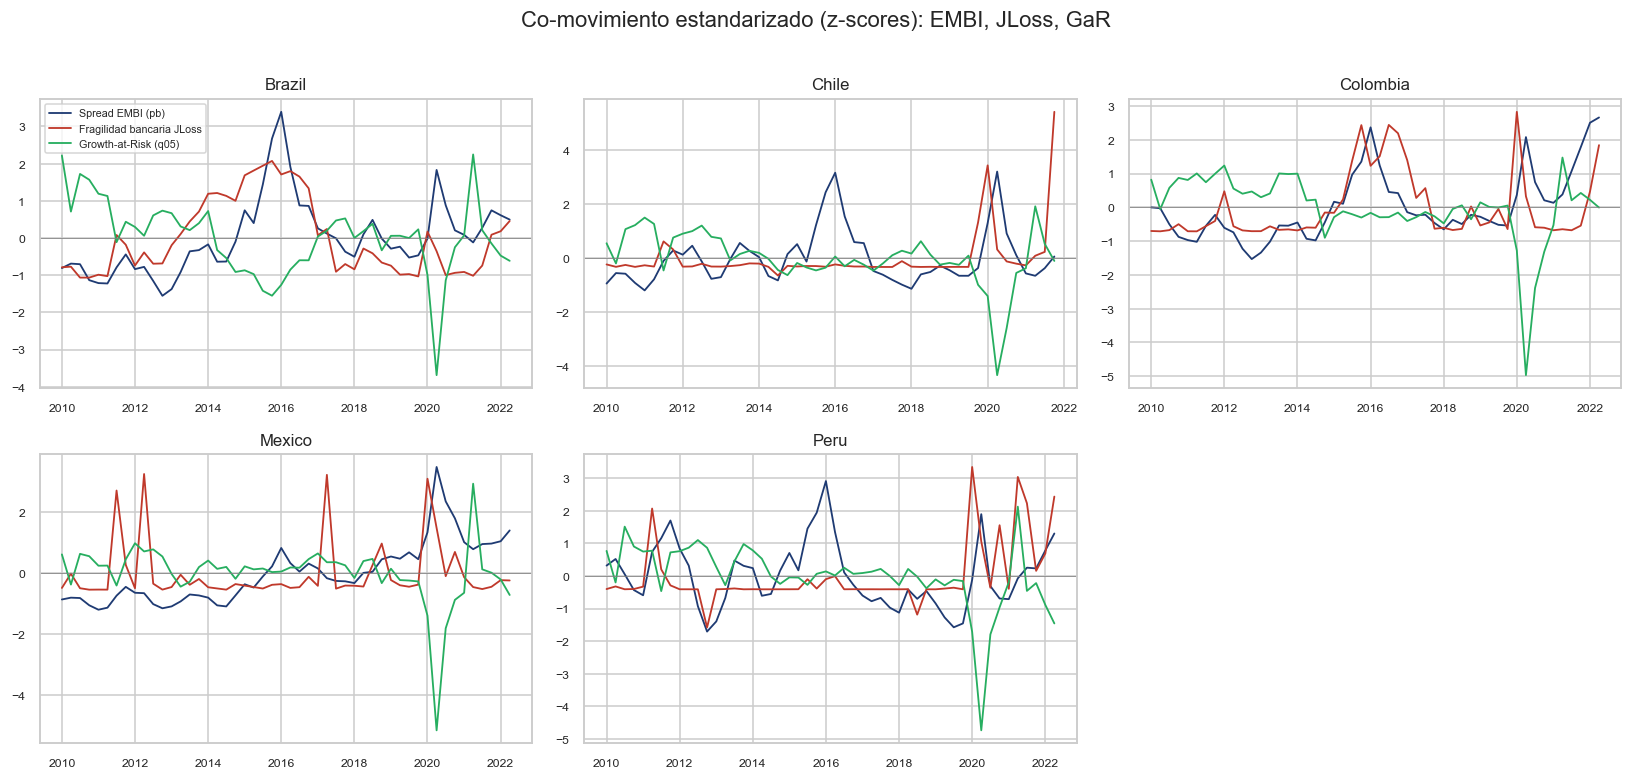

In [13]:
# EMBI, JLoss y GaR superpuestos por país (triple eje conceptual via estandarización)
fig, axes = plt.subplots(2,3, figsize=(15,7)); axes=axes.ravel()
for i,(c,g) in enumerate(df.groupby('country')):
    g=g.sort_values('date')
    for v,col in [('EMBI_bps','#1f3b73'),('JLoss','#c0392b'),('GaR','#27ae60')]:
        z=(g[v]-g[v].mean())/g[v].std()
        axes[i].plot(g['date'], z, color=col, lw=1.2, label=LABELS[v])
    axes[i].set_title(c.capitalize()); axes[i].tick_params(labelsize=8)
    axes[i].axhline(0, color='grey', lw=.5)
axes[-1].axis('off'); axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('Co-movimiento estandarizado (z-scores): EMBI, JLoss, GaR', y=1.01)
plt.tight_layout(); savefig('05_comovimiento'); plt.show()

## 6. Relaciones bivariadas y la interacción central

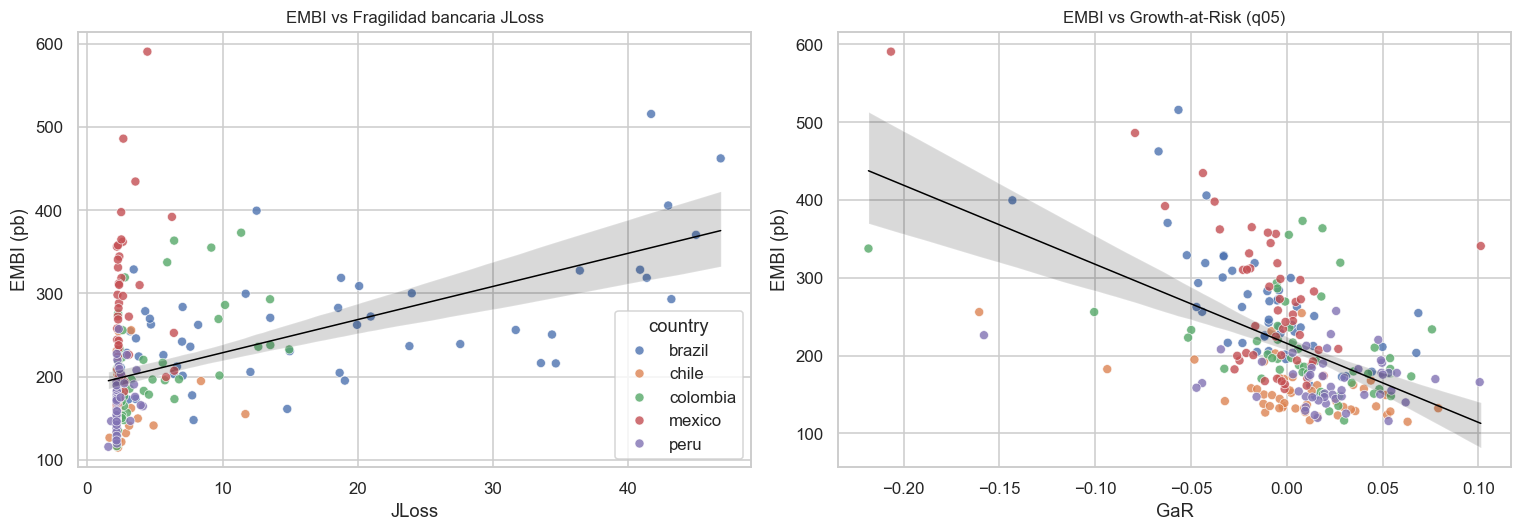

In [14]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
for ax,v in zip(axes, ['JLoss','GaR']):
    sns.scatterplot(data=df, x=v, y='EMBI_bps', hue='country', ax=ax, s=35, alpha=.8)
    sns.regplot(data=df, x=v, y='EMBI_bps', scatter=False, ax=ax, color='black', line_kws={'lw':1})
    ax.set_title(f'EMBI vs {LABELS[v]}'); ax.set_ylabel('EMBI (pb)')
    if v!='JLoss': ax.legend_.remove()
plt.tight_layout(); savefig('06_scatter_embi'); plt.show()

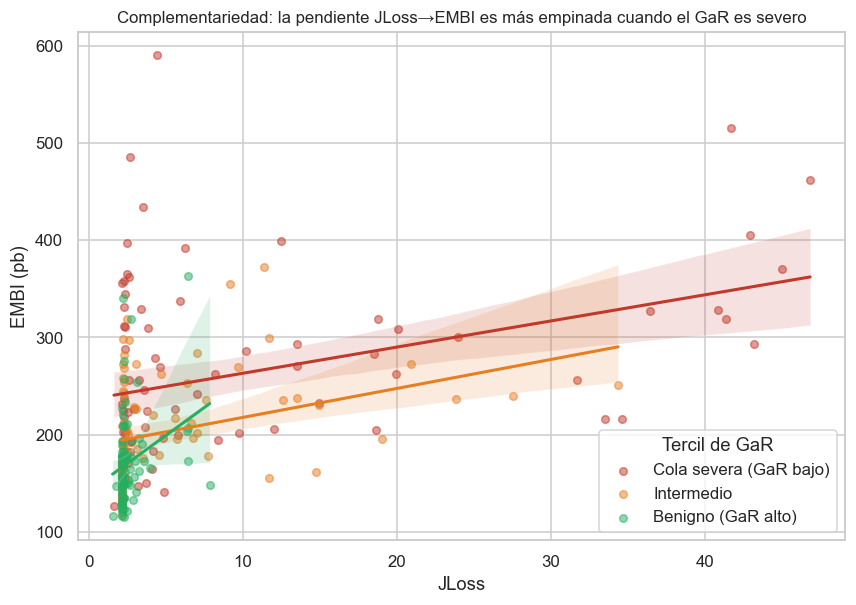

In [15]:
# Visualización de la COMPLEMENTARIEDAD: relación JLoss–EMBI según severidad de la cola (terciles de GaR)
df['GaR_tercil'] = pd.qcut(df['GaR'], 3, labels=['Cola severa (GaR bajo)','Intermedio','Benigno (GaR alto)'])
fig, ax = plt.subplots(figsize=(9,6))
palette = {'Cola severa (GaR bajo)':'#c0392b','Intermedio':'#e67e22','Benigno (GaR alto)':'#27ae60'}
for terc,g in df.groupby('GaR_tercil', observed=True):
    sns.regplot(data=g, x='JLoss', y='EMBI_bps', scatter_kws={'s':25,'alpha':.5},
                line_kws={'lw':2}, color=palette[terc], label=str(terc), ax=ax)
ax.set_title('Complementariedad: la pendiente JLoss→EMBI es más empinada cuando el GaR es severo')
ax.set_xlabel('JLoss'); ax.set_ylabel('EMBI (pb)'); ax.legend(title='Tercil de GaR')
savefig('06_complementariedad'); plt.show()

## 7. Matriz de correlaciones

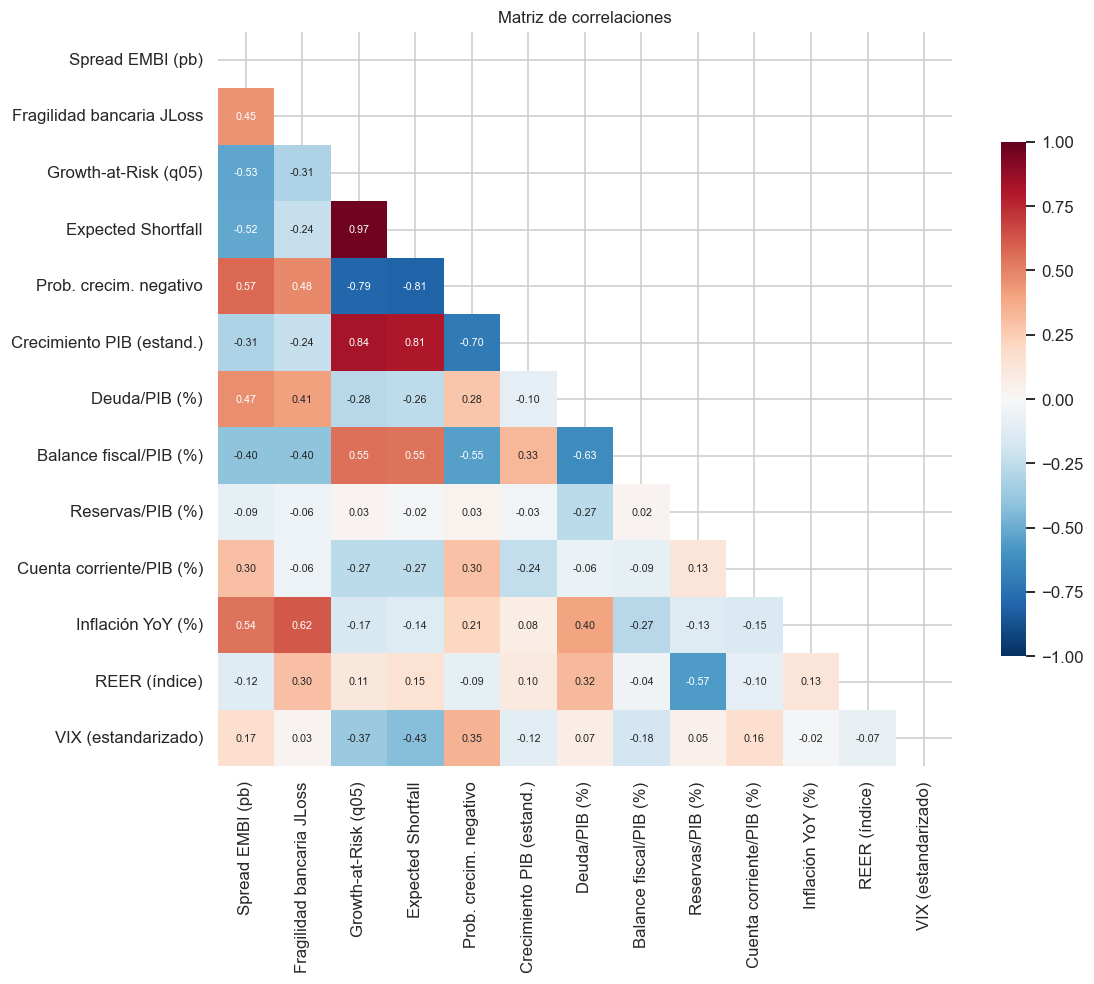


Pares con |corr|>0.6 (vigilar en regresión):
  Fragilidad bancaria JLoss ~ Inflación YoY (%): +0.619
  Growth-at-Risk (q05) ~ Expected Shortfall: +0.974
  Growth-at-Risk (q05) ~ Prob. crecim. negativo: -0.795
  Growth-at-Risk (q05) ~ Crecimiento PIB (estand.): +0.835
  Expected Shortfall ~ Prob. crecim. negativo: -0.806
  Expected Shortfall ~ Crecimiento PIB (estand.): +0.809
  Prob. crecim. negativo ~ Crecimiento PIB (estand.): -0.705
  Deuda/PIB (%) ~ Balance fiscal/PIB (%): -0.627

Nota: GaR–crecimiento alta por construcción (GaR es un cuantil del crecimiento) -> NO incluir g_GDP junto a GaR.


In [16]:
corr_vars = CORE + ['g_GDP'] + CTRLS
cm = df[corr_vars].corr()
cm.index=[LABELS.get(c,c) for c in corr_vars]; cm.columns=[LABELS.get(c,c) for c in corr_vars]
fig, ax = plt.subplots(figsize=(11,9))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink':.7}, annot_kws={'size':7}, ax=ax)
ax.set_title('Matriz de correlaciones'); plt.tight_layout(); savefig('07_correlaciones'); plt.show()
cm.round(3).to_csv(OUTDIR/'matriz_correlaciones.csv')

# Alertas de multicolinealidad
print('\nPares con |corr|>0.6 (vigilar en regresión):')
cc = df[corr_vars].corr().abs()
for i in range(len(corr_vars)):
    for j in range(i+1,len(corr_vars)):
        if cc.iloc[i,j]>0.6:
            print(f'  {LABELS.get(corr_vars[i])} ~ {LABELS.get(corr_vars[j])}: {df[corr_vars].corr().iloc[i,j]:+.3f}')
print('\nNota: GaR–crecimiento alta por construcción (GaR es un cuantil del crecimiento) -> NO incluir g_GDP junto a GaR.')

In [17]:
# VIF (factor de inflación de varianza) para el bloque de regresores
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
vif_vars = ['JLoss','GaR','fisc_bal','res_gdp','ca_gdp','infl_yoy','reer','VIX']
X = add_constant(df[vif_vars].dropna())
vif = pd.DataFrame({'variable':[LABELS.get(v,v) for v in vif_vars],
    'VIF':[variance_inflation_factor(X.values, i+1) for i in range(len(vif_vars))]}).round(2)
print(vif.to_string(index=False))
print('\nRegla práctica: VIF>10 indica multicolinealidad problemática.')

                 variable    VIF
Fragilidad bancaria JLoss 2.2100
     Growth-at-Risk (q05) 1.9000
   Balance fiscal/PIB (%) 1.5800
         Reservas/PIB (%) 1.6700
 Cuenta corriente/PIB (%) 1.1500
        Inflación YoY (%) 1.7400
            REER (índice) 1.8900
      VIX (estandarizado) 1.1800

Regla práctica: VIF>10 indica multicolinealidad problemática.


## 8. Descomposición de varianza *within / between*

Para un panel con efectos fijos, lo que identifica los coeficientes es la variación **within**
(dentro de cada país en el tiempo). Aquí se reporta, estilo `xtsum` de Stata, cuánta variación
es total, entre países (*between*) y dentro de país (*within*).

In [18]:
def xtsum(d, var, group='country'):
    overall = d[var].std()
    between = d.groupby(group)[var].mean().std()
    gmean = d.groupby(group)[var].transform('mean')
    within = (d[var]-gmean + d[var].mean()).std()
    return overall, between, within

rows=[]
for v in CORE+['g_GDP','debt_gdp','fisc_bal','res_gdp','ca_gdp','infl_yoy','reer']:
    o,b,w = xtsum(df, v)
    rows.append({'variable':LABELS.get(v,v),'sd_total':o,'sd_between':b,'sd_within':w,
                 'within/total':w/o if o else np.nan})
vardec = pd.DataFrame(rows).round(3)
vardec.to_csv(OUTDIR/'descomposicion_within_between.csv', index=False)
print(vardec.to_string(index=False))
print('\nLectura: variables con within/total alto aportan más a la identificación con efectos fijos.')

                 variable  sd_total  sd_between  sd_within  within/total
         Spread EMBI (pb)   78.4110     52.9030    62.5370        0.7980
Fragilidad bancaria JLoss    8.7860      6.5010     6.5620        0.7470
     Growth-at-Risk (q05)    0.0410      0.0140     0.0390        0.9540
       Expected Shortfall    0.0520      0.0140     0.0510        0.9720
   Prob. crecim. negativo    0.2750      0.0880     0.2630        0.9580
Crecimiento PIB (estand.)    1.1670      0.1870     1.1550        0.9900
            Deuda/PIB (%)   23.8140     24.6920     8.8950        0.3740
   Balance fiscal/PIB (%)    2.6630      1.4680     2.3140        0.8690
         Reservas/PIB (%)    7.0400      7.3520     2.4280        0.3450
 Cuenta corriente/PIB (%)    1.7110      1.2080     1.3240        0.7740
        Inflación YoY (%)    1.8090      1.1410     1.4920        0.8240
            REER (índice)   19.5130     14.0680    14.8540        0.7610

Lectura: variables con within/total alto aportan m

## 9. Persistencia (autocorrelación) del spread y de JLoss

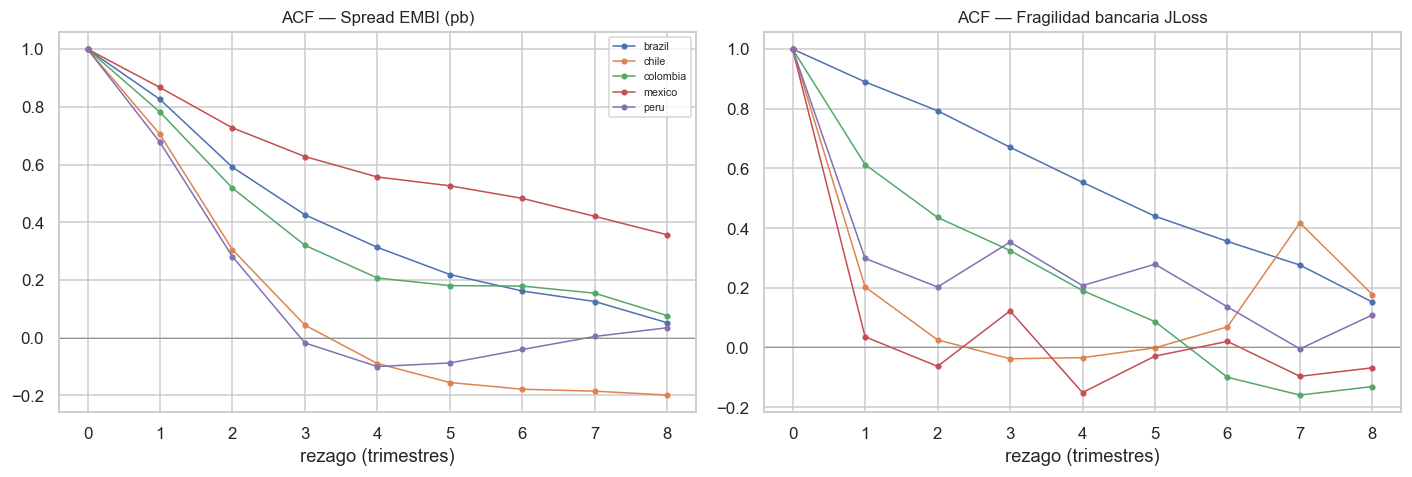

Spreads y JLoss muy persistentes -> motiva SE robustos a autocorrelación (Driscoll-Kraay) y/o specs dinámicas como robustez.


In [19]:
from statsmodels.tsa.stattools import acf
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
for ax,v in zip(axes, ['EMBI_bps','JLoss']):
    for c,g in df.groupby('country'):
        a = acf(g.sort_values('t')[v].values, nlags=8, fft=False)
        ax.plot(range(len(a)), a, marker='o', ms=3, label=c, lw=1)
    ax.axhline(0, color='grey', lw=.5); ax.set_title(f'ACF — {LABELS[v]}')
    ax.set_xlabel('rezago (trimestres)')
axes[0].legend(fontsize=7)
plt.tight_layout(); savefig('09_persistencia'); plt.show()
print('Spreads y JLoss muy persistentes -> motiva SE robustos a autocorrelación (Driscoll-Kraay) y/o specs dinámicas como robustez.')

## 10. Episodios de estrés: medias por régimen de mercado global

In [20]:
# clasificar trimestres por nivel global de VIX (terciles) y comparar medias
df['regimen_VIX'] = pd.qcut(df['VIX'], 3, labels=['VIX bajo','VIX medio','VIX alto'])
tab = df.groupby('regimen_VIX', observed=True)[['EMBI_bps','JLoss','GaR','prob_neg']].mean().round(3)
print(tab.to_string())
tab.to_csv(OUTDIR/'medias_por_regimen_VIX.csv')

             EMBI_bps  JLoss     GaR  prob_neg
regimen_VIX                                   
VIX bajo     207.8280 6.6820  0.0070    0.1140
VIX medio    191.4980 4.9250  0.0230    0.0510
VIX alto     239.7670 6.5240 -0.0220    0.2830


## 11. Detección de atípicos

In [21]:
z = (df[CORE] - df[CORE].mean())/df[CORE].std()
out = df.loc[(z.abs()>3).any(axis=1), ['country','quarter']+CORE]
print(f'Observaciones con |z|>3 en alguna variable central: {len(out)}')
out.round(3)

Observaciones con |z|>3 en alguna variable central: 19


,country,quarter,EMBI_bps,JLoss,GaR,ES,prob_neg
16,brazil,2014Q1,250.7140,34.3580,0.0140,0.0110,0.0000
17,brazil,2014Q2,216.0460,34.6410,-0.0230,-0.0260,0.2830
18,brazil,2014Q3,216.4050,33.5410,-0.0310,-0.0380,0.4370
20,brazil,2015Q1,318.8170,41.3640,-0.0430,-0.0470,0.8760
21,brazil,2015Q2,293.2420,43.1870,-0.0460,-0.0510,0.8710
22,brazil,2015Q3,370.4680,45.0100,-0.0620,-0.0810,0.9640
23,brazil,2015Q4,462.3320,46.8330,-0.0670,-0.0790,0.9570
24,brazil,2016Q1,515.7100,41.6890,-0.0570,-0.0720,0.9630
25,brazil,2016Q2,405.7090,42.9530,-0.0420,-0.0530,0.9170
26,brazil,2016Q3,328.5720,40.8730,-0.0330,-0.0410,0.9050


## 12. Resumen de archivos exportados
Todo en la carpeta `eda_output/` (tablas) y `eda_output/figuras/` (PNG).

In [22]:
import os
print('Tablas:'); [print('  ', f) for f in sorted(os.listdir(OUTDIR)) if f.endswith(('.csv','.tex'))]
print('Figuras:'); [print('  ', f) for f in sorted(os.listdir(FIGDIR))]

Tablas:
   descomposicion_within_between.csv
   matriz_correlaciones.csv
   medias_por_regimen_VIX.csv
   tabla_descriptiva_global.csv
   tabla_descriptiva_global.tex
   tabla_descriptiva_por_pais.csv
Figuras:
   01_balance_panel.png
   04_distribuciones.png
   04b_boxplots_pais.png
   05_comovimiento.png
   05_ts_embi.png
   05_ts_gar.png
   05_ts_jloss.png
   06_complementariedad.png
   06_scatter_embi.png
   07_correlaciones.png
   09_persistencia.png
   13_anchura_colas.png
   13_cola_izquierda.png
   13_curva_gar_chile.png
   13_volatilidad_gar.png


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

---
# 13. Análisis del GaR: volatilidad, anchura de colas y forma de la distribución

Esta sección usa `gar_panel_latam.csv`, que conserva los momentos completos de la
distribución condicional del crecimiento (media, dispersión, anchura intercuantil 5–95,
*Expected Shortfall* y los parámetros del ajuste skew-t) necesarios para estudiar la
**forma** de la cola y su evolución temporal.

In [23]:
# Carga del panel GaR con momentos completos
gar = pd.read_csv('gar_panel_latam.csv')
gar['country'] = gar['country'].str.lower()
gar['t'] = pd.PeriodIndex(gar['quarter'], freq='Q')
gar['date'] = gar['t'].dt.to_timestamp()
gar = gar.sort_values(['country','t']).reset_index(drop=True)
gar[['country','quarter','GaR','GaR_st','ES','mean','std','iqr_05_95',
     'scale_st','skew_st','nu_st']].head()

,country,quarter,GaR,GaR_st,ES,mean,std,iqr_05_95,scale_st,skew_st,nu_st
0,brazil,2010Q1,0.0676,0.0676,0.0586,0.0915,0.0126,0.0567,0.0119,0.6302,2.1000
1,brazil,2010Q2,0.0138,0.0133,0.0134,0.0546,0.0169,0.0622,0.0156,-0.9006,2.1000
2,brazil,2010Q3,0.0500,0.0502,0.0265,0.0716,0.0106,0.0538,0.0112,0.6307,2.1000
3,brazil,2010Q4,0.0444,0.0446,0.0325,0.0660,0.0119,0.0571,0.0126,0.7461,2.1000
4,brazil,2011Q1,0.0310,0.0313,0.0259,0.0561,0.0124,0.0638,0.0143,0.7832,2.1000


## 13.1 Volatilidad del GaR

Dos lecturas complementarias de la volatilidad: (i) la **dispersión condicional** `std`
estimada en cada corte —cuánta incertidumbre rodea al pronóstico de crecimiento— y
(ii) la **volatilidad realizada** del propio GaR (desviación estándar móvil de 4
trimestres), que mide cuán inestable es la estimación del riesgo de cola en el tiempo.

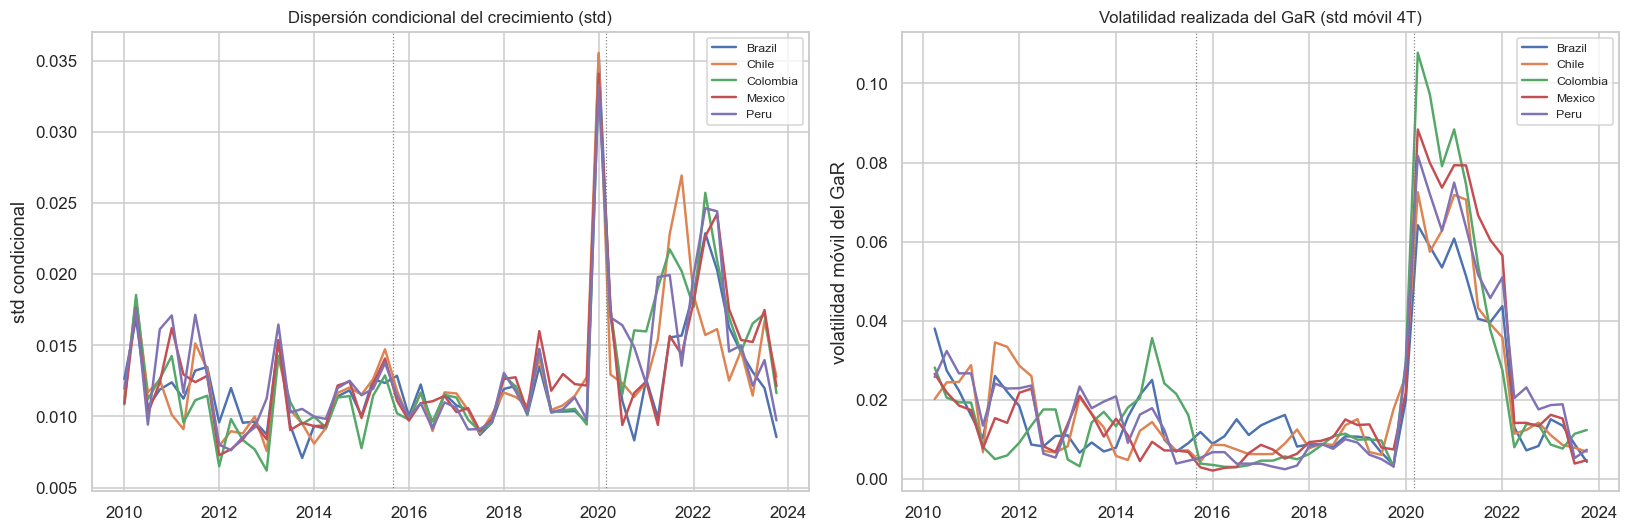

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (i) dispersión condicional por país
for c, g in gar.groupby('country'):
    axes[0].plot(g['date'], g['std'], lw=1.6, label=c.capitalize())
axes[0].set_title('Dispersión condicional del crecimiento (std)')
axes[0].set_ylabel('std condicional'); axes[0].legend(fontsize=8)
for yr in ['2015-09','2020-03']:
    axes[0].axvline(pd.Timestamp(yr), color='grey', ls=':', lw=.8)

# (ii) volatilidad realizada (móvil) del GaR
gar['GaR_vol4'] = gar.groupby('country')['GaR'].transform(
    lambda s: s.rolling(4, min_periods=2).std())
for c, g in gar.groupby('country'):
    axes[1].plot(g['date'], g['GaR_vol4'], lw=1.6, label=c.capitalize())
axes[1].set_title('Volatilidad realizada del GaR (std móvil 4T)')
axes[1].set_ylabel('volatilidad móvil del GaR'); axes[1].legend(fontsize=8)
for yr in ['2015-09','2020-03']:
    axes[1].axvline(pd.Timestamp(yr), color='grey', ls=':', lw=.8)
plt.tight_layout(); savefig('13_volatilidad_gar'); plt.show()

## 13.2 Anchura de las colas y su evolución temporal

Para cada país se reconstruye el **intervalo condicional 5–95%** del crecimiento usando
el cuantil inferior (`GaR` = percentil 5) y la anchura intercuantil (`iqr_05_95`), de
modo que el percentil 95 = `GaR + iqr_05_95`. La banda sombreada representa el rango
central de la distribución; su ensanchamiento señala mayor incertidumbre. La línea de
*Expected Shortfall* (`ES`, media de la cola izquierda) marca la profundidad de la cola
adversa. Las colas se ensanchan visiblemente en los episodios de estrés.

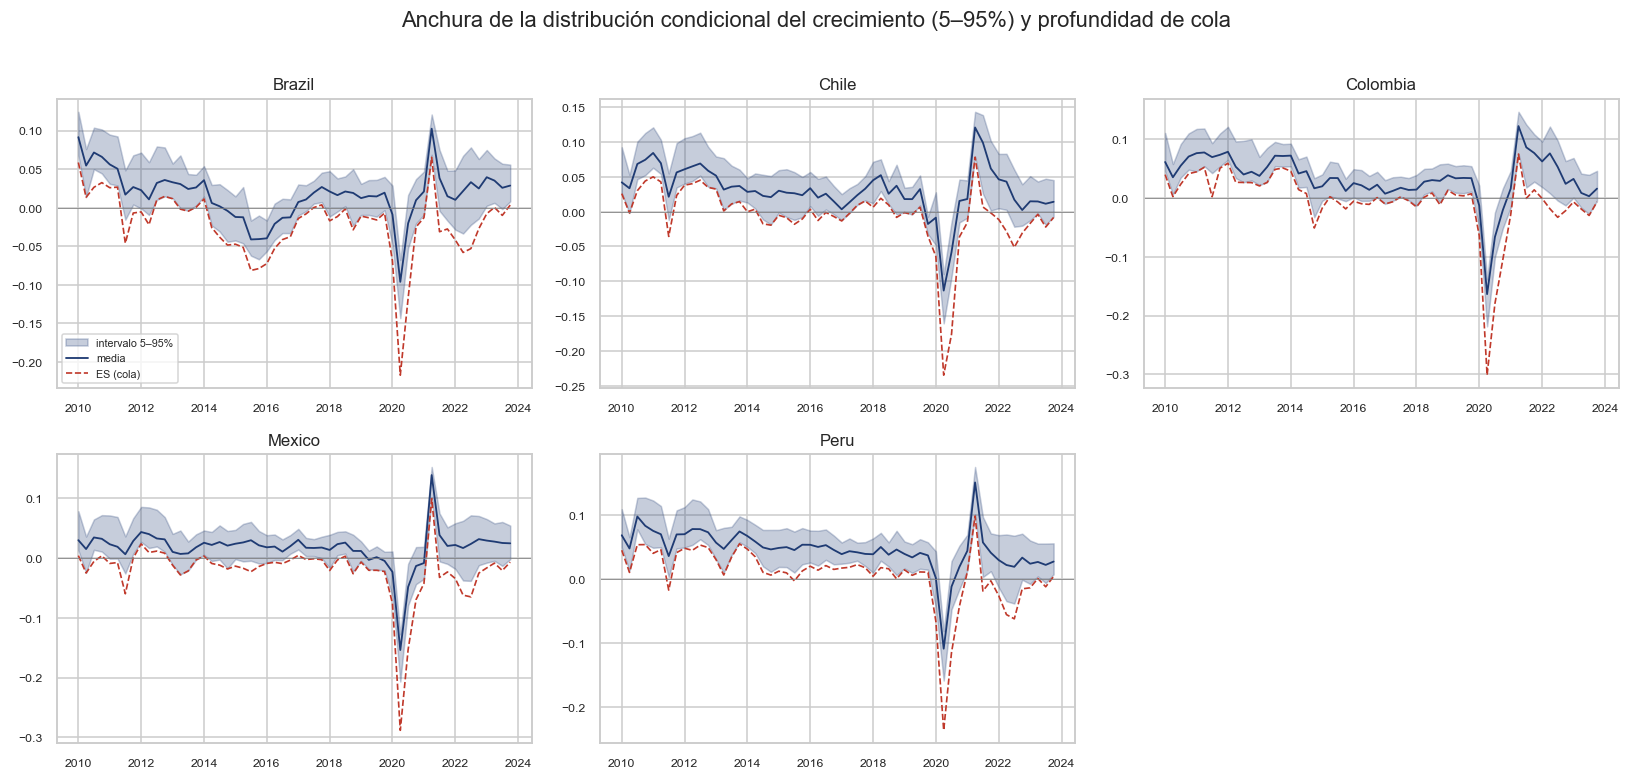

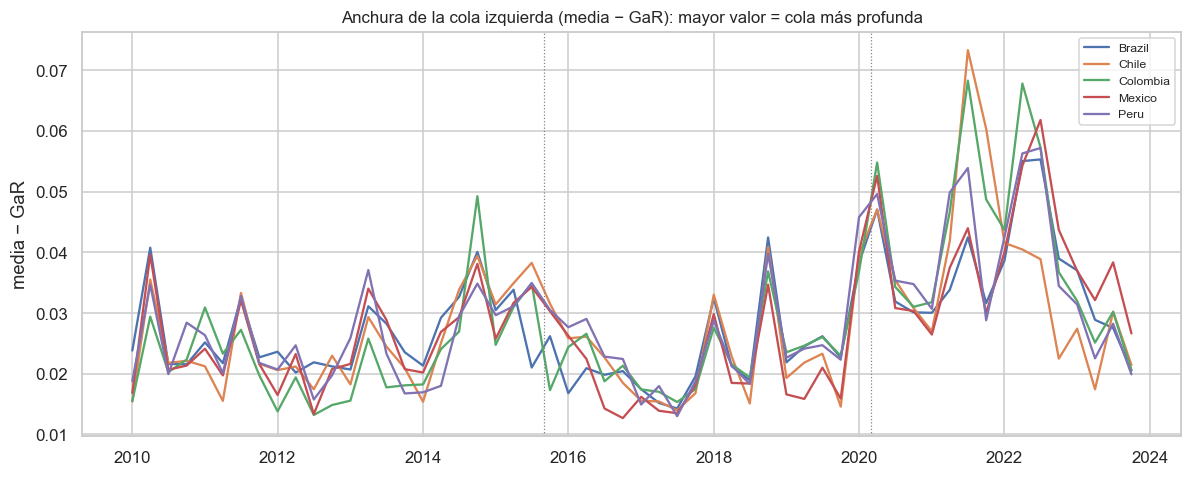

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7)); axes = axes.ravel()
for i, (c, g) in enumerate(gar.groupby('country')):
    g = g.sort_values('date')
    q05 = g['GaR']; q95 = g['GaR'] + g['iqr_05_95']
    axes[i].fill_between(g['date'], q05, q95, alpha=.25, color='#1f3b73',
                         label='intervalo 5–95%')
    axes[i].plot(g['date'], g['mean'], color='#1f3b73', lw=1.2, label='media')
    axes[i].plot(g['date'], g['ES'], color='#c0392b', lw=1.1, ls='--', label='ES (cola)')
    axes[i].axhline(0, color='grey', lw=.5)
    axes[i].set_title(c.capitalize()); axes[i].tick_params(labelsize=8)
axes[-1].axis('off'); axes[0].legend(fontsize=7, loc='lower left')
fig.suptitle('Anchura de la distribución condicional del crecimiento (5–95%) y profundidad de cola', y=1.01)
plt.tight_layout(); savefig('13_anchura_colas'); plt.show()

# Anchura de cola IZQUIERDA (media - GaR) por país en el tiempo
fig, ax = plt.subplots(figsize=(11,4.5))
for c, g in gar.groupby('country'):
    ax.plot(g['date'], g['mean'] - g['GaR'], lw=1.5, label=c.capitalize())
ax.set_title('Anchura de la cola izquierda (media − GaR): mayor valor = cola más profunda')
ax.set_ylabel('media − GaR'); ax.legend(fontsize=8)
for yr in ['2015-09','2020-03']: ax.axvline(pd.Timestamp(yr), color='grey', ls=':', lw=.8)
plt.tight_layout(); savefig('13_cola_izquierda'); plt.show()

## 13.3 Forma de la distribución del GaR para Chile en momentos específicos

Se reconstruye la **densidad condicional skew-t** (Azzalini; especificación de Adrian,
Boyarchenko y Giannone, 2019) a partir de los parámetros estimados —escala $\omega$
(`scale_st`), asimetría $\alpha$ (`skew_st`) y grados de libertad $\nu$ (`nu_st`)—,
recuperando la localización $\xi$ a partir de la media condicional. Se contrastan un
trimestre de **estrés** (GaR más negativo) y uno **benigno** para Chile, marcando el
cuantil 5% (GaR) y el *Expected Shortfall*. El desplazamiento a la izquierda y el
engrosamiento de la cola en el trimestre de estrés son la representación gráfica directa
del *growth-at-risk*.

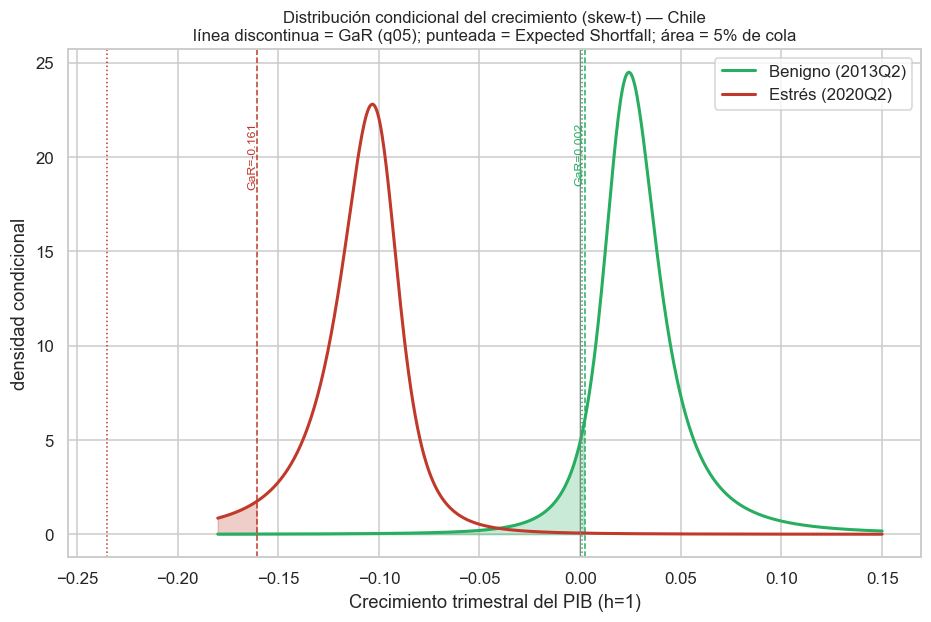

2013Q2: q05 skew-t reconstruido=-0.0043 | GaR_st reportado=0.0028 | GaR (directo)=0.0023
2020Q2: q05 skew-t reconstruido=-0.1491 | GaR_st reportado=-0.1597 | GaR (directo)=-0.1605


In [26]:
from scipy.stats import t as student_t
from scipy.special import gammaln

def skewt_pdf(y, xi, omega, alpha, nu):
    z = (y - xi) / omega
    arg = alpha * z * np.sqrt((nu + 1) / (z**2 + nu))
    return (2/omega) * student_t.pdf(z, nu) * student_t.cdf(arg, nu + 1)

def xi_from_mean(mean, omega, alpha, nu):
    # E[Y] = xi + omega*delta*sqrt(nu/pi)*Gamma((nu-1)/2)/Gamma(nu/2),  nu>1
    delta = alpha / np.sqrt(1 + alpha**2)
    b = np.sqrt(nu/np.pi) * np.exp(gammaln((nu-1)/2) - gammaln(nu/2))
    return mean - omega * delta * b

ch = gar[gar.country == 'chile'].copy()
q_stress = ch.loc[ch['GaR'].idxmin(), 'quarter']                 # cola más severa
q_calm   = ch.loc[(ch['GaR'] - ch['GaR'].median()).abs().idxmin(), 'quarter']  # típico

fig, ax = plt.subplots(figsize=(10, 6))
ygrid = np.linspace(-0.18, 0.15, 600)
for q, col, lab in [(q_calm, '#27ae60', f'Benigno ({q_calm})'),
                    (q_stress, '#c0392b', f'Estrés ({q_stress})')]:
    r = ch[ch.quarter == q].iloc[0]
    xi = xi_from_mean(r['mean'], r['scale_st'], r['skew_st'], r['nu_st'])
    dens = skewt_pdf(ygrid, xi, r['scale_st'], r['skew_st'], r['nu_st'])
    ax.plot(ygrid, dens, color=col, lw=2, label=lab)
    # sombrear cola 5% por debajo del GaR
    tail = ygrid <= r['GaR']
    ax.fill_between(ygrid[tail], dens[tail], alpha=.25, color=col)
    ax.axvline(r['GaR'], color=col, ls='--', lw=1)
    ax.axvline(r['ES'],  color=col, ls=':',  lw=1)
    ax.annotate(f"GaR={r['GaR']:.3f}", (r['GaR'], ax.get_ylim()[1]*0.85),
                color=col, fontsize=8, rotation=90, va='top', ha='right')

ax.axvline(0, color='grey', lw=.6)
ax.set_xlabel('Crecimiento trimestral del PIB (h=1)')
ax.set_ylabel('densidad condicional')
ax.set_title('Distribución condicional del crecimiento (skew-t) — Chile\n'
             'línea discontinua = GaR (q05); punteada = Expected Shortfall; área = 5% de cola')
ax.legend()
savefig('13_curva_gar_chile'); plt.show()

# Verificación: cuantil 5% numérico de la skew-t vs GaR_st reportado
from scipy.integrate import cumulative_trapezoid
for q in [q_calm, q_stress]:
    r = ch[ch.quarter == q].iloc[0]
    xi = xi_from_mean(r['mean'], r['scale_st'], r['skew_st'], r['nu_st'])
    d = skewt_pdf(ygrid, xi, r['scale_st'], r['skew_st'], r['nu_st'])
    cdf = cumulative_trapezoid(d, ygrid, initial=0); cdf /= cdf[-1]
    q05_num = ygrid[np.searchsorted(cdf, 0.05)]
    print(f'{q}: q05 skew-t reconstruido={q05_num:.4f} | GaR_st reportado={r["GaR_st"]:.4f} | GaR (directo)={r["GaR"]:.4f}')

---
# 14. Figuras de resultados (basadas en las regresiones)

Esta sección reestima los modelos del Cuadro 1 con `linearmodels` (efectos fijos + SE
Driscoll–Kraay) y construye las figuras que sostienen el argumento. Los puntos estimados
coinciden con la salida de R (plm + `vcovSCC`): θ = −0.352 (M2), −0.363 (M3), −0.239 (M5).

**Requiere `Panel_final.csv` con `debt_gdp` completo** (parche del BCCh para Chile).

In [27]:
import warnings; warnings.filterwarnings('ignore')
from linearmodels.panel import PanelOLS

# --- panel y variables (consistentes con el .Rmd) ---
P = pd.read_csv('Panel_final.csv')
P['t']  = pd.PeriodIndex(P['quarter'], freq='Q').to_timestamp()
P['date'] = pd.PeriodIndex(P['quarter'], freq='Q').to_timestamp()
P['GaR_pp'] = P['GaR']*100; P['ES_pp'] = P['ES']*100
for v in ['JLoss','GaR_pp','ES_pp']: P[v+'_c'] = P[v]-P[v].mean()
P['JxG_c']  = P['JLoss_c']*P['GaR_pp_c']
P['JxES_c'] = P['JLoss_c']*P['ES_pp_c']
CTRL = ['debt_gdp','fisc_bal','res_gdp','ca_gdp','infl_yoy','reer']
FC = ' + '.join(CTRL)
Pi = P.set_index(['country','t'])
DK = dict(cov_type='kernel', kernel='bartlett')
def feols(form, **kw): return PanelOLS.from_formula(form, Pi, **kw).fit(**DK)

# Modelo controlado de referencia (M3) para las figuras
m3 = feols(f'EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + {FC} + EntityEffects + TimeEffects')
b1, b2, th = m3.params['JLoss_c'], m3.params['GaR_pp_c'], m3.params['JxG_c']
V  = m3.cov
mu_g = P['GaR_pp'].mean()
print(f'M3:  beta1(JLoss)={b1:.3f}   beta2(GaR)={b2:.3f}   theta={th:.3f}')

M3:  beta1(JLoss)=1.119   beta2(GaR)=1.421   theta=-0.363


## 14.1 Efecto marginal de JLoss condicional al GaR — figura central

$$\partial EMBI/\partial JLoss = \hat\beta_1 + \hat\theta\,(GaR-\overline{GaR})$$
con banda IC95%, marcadores en p10/mediana/p90, *rug plot* de la distribución del GaR y
el cruce por cero. Análoga a la Fig. 3 de Chari et al. (2024).

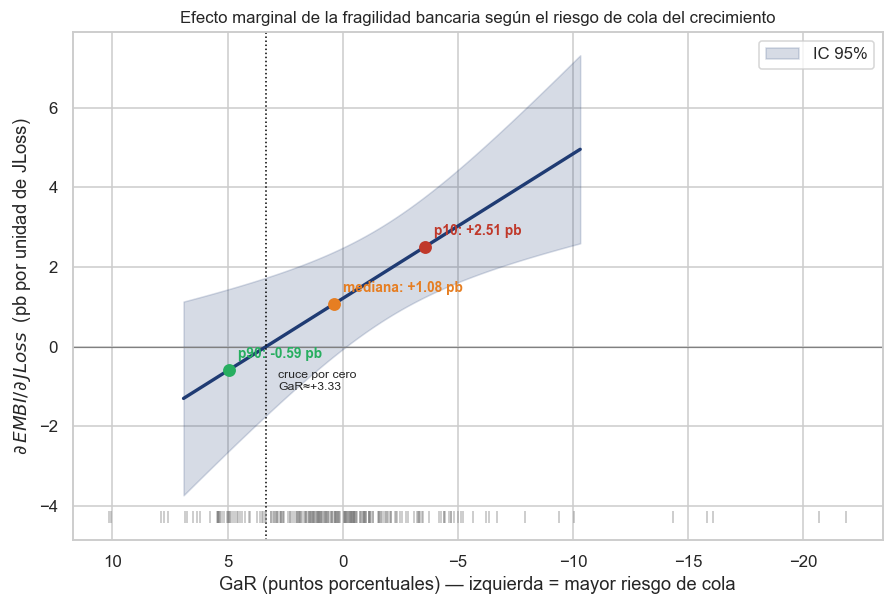

In [28]:
bJ, bI = b1, th
vJ, vI, cJI = V.loc['JLoss_c','JLoss_c'], V.loc['JxG_c','JxG_c'], V.loc['JLoss_c','JxG_c']

grid = np.linspace(P['GaR_pp'].quantile(.02), P['GaR_pp'].quantile(.98), 200)
dev  = grid - mu_g
me   = bJ + bI*dev
se   = np.sqrt(vJ + dev**2*vI + 2*dev*cJI)
lo, hi = me-1.96*se, me+1.96*se
cross = mu_g - bJ/bI          # GaR donde el efecto cruza cero

fig, ax = plt.subplots(figsize=(9.5,6))
ax.axhline(0, color='grey', lw=.8)
ax.fill_between(grid, lo, hi, alpha=.18, color='#1f3b73', label='IC 95%')
ax.plot(grid, me, color='#1f3b73', lw=2.2)
# marcadores p10/mediana/p90
for qq,lab,col in [(.10,'p10',' #c0392b'.strip()),(.50,'mediana','#e67e22'),(.90,'p90','#27ae60')]:
    g = P['GaR_pp'].quantile(qq); e = bJ + bI*(g-mu_g)
    ax.scatter([g],[e], color=col, zorder=5, s=55)
    ax.annotate(f'{lab}: {e:+.2f} pb', (g,e), textcoords='offset points',
                xytext=(6,8), fontsize=9, color=col, fontweight='bold')
# cruce por cero
ax.axvline(cross, color='black', ls=':', lw=1)
ax.annotate(f'cruce por cero\nGaR≈{cross:+.2f}', (cross,0), textcoords='offset points',
            xytext=(8,-28), fontsize=8)
# rug plot de la distribución del GaR
ax.plot(P['GaR_pp'], np.full(len(P), ax.get_ylim()[0]), '|', color='grey',
        alpha=.5, ms=8)
ax.set_xlabel('GaR (puntos porcentuales) — izquierda = mayor riesgo de cola')
ax.set_ylabel(r'$\partial\,EMBI/\partial\,JLoss$  (pb por unidad de JLoss)')
ax.set_title('Efecto marginal de la fragilidad bancaria según el riesgo de cola del crecimiento')
ax.invert_xaxis(); ax.legend(loc='upper right')
savefig('14_efecto_marginal'); plt.show()

## 14.2 Superficie de complementariedad

Componente $\hat\beta_1 JLoss + \hat\beta_2 GaR + \hat\theta(JLoss\times GaR)$ sobre
la malla $(JLoss, GaR)$. Las curvas de iso-spread se "doblan" hacia la esquina de alta
fragilidad y cola severa: la representación geométrica de que los riesgos se potencian.

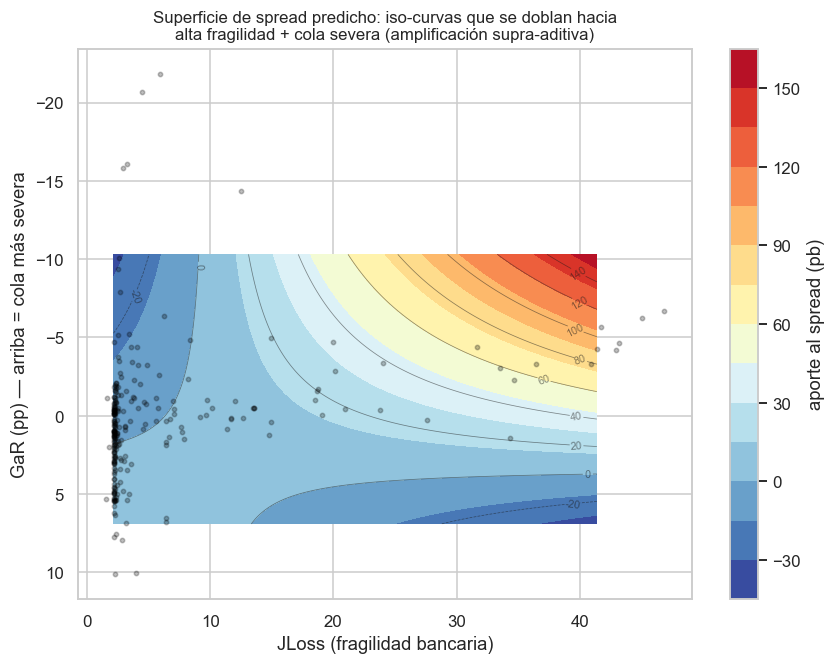

In [29]:
jg = np.linspace(P['JLoss'].quantile(.02), P['JLoss'].quantile(.98), 120)
gg = np.linspace(P['GaR_pp'].quantile(.02), P['GaR_pp'].quantile(.98), 120)
JJ, GG = np.meshgrid(jg, gg)
# en variables centradas (igual que la regresión)
S = b1*(JJ-P['JLoss'].mean()) + b2*(GG-mu_g) + th*((JJ-P['JLoss'].mean())*(GG-mu_g))

fig, ax = plt.subplots(figsize=(9,6.5))
cf = ax.contourf(JJ, GG, S, levels=18, cmap='RdYlBu_r')
cs = ax.contour(JJ, GG, S, levels=10, colors='k', linewidths=.5, alpha=.5)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.0f')
ax.scatter(P['JLoss'], P['GaR_pp'], s=8, color='black', alpha=.25)  # nube de datos
ax.invert_yaxis()  # cola severa (GaR bajo) hacia arriba
ax.set_xlabel('JLoss (fragilidad bancaria)')
ax.set_ylabel('GaR (pp) — arriba = cola más severa')
ax.set_title('Superficie de spread predicho: iso-curvas que se doblan hacia\nalta fragilidad + cola severa (amplificación supra-aditiva)')
fig.colorbar(cf, ax=ax, label='aporte al spread (pb)')
savefig('14_superficie_complementariedad'); plt.show()

## 14.3 Binscatter de EMBI vs JLoss por régimen de GaR

Validación visual **no paramétrica** del Cuadro 1: la pendiente JLoss→EMBI se empina en
el régimen de cola severa. Se promedia el EMBI en deciles de JLoss dentro de cada tercil
de GaR (binscatter), con recta ajustada por grupo.

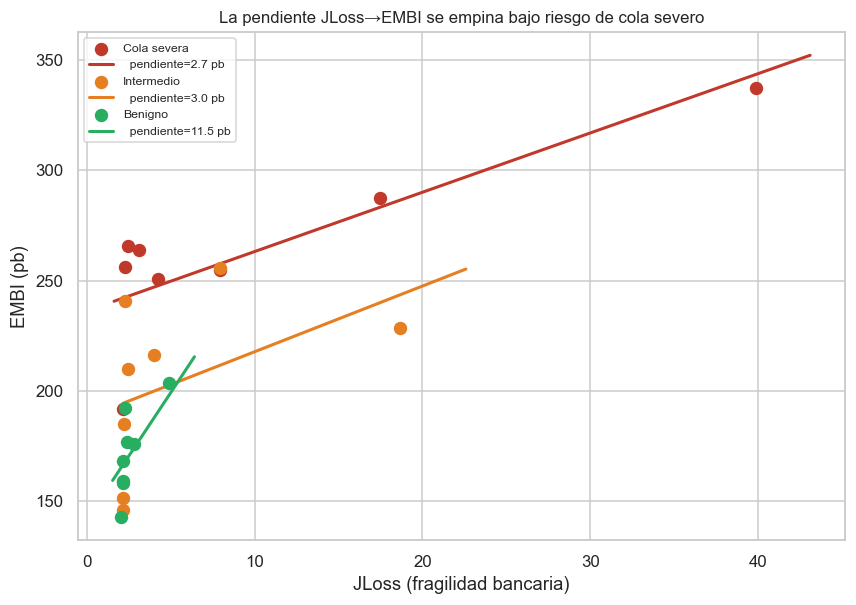

In [30]:
dd = P.copy()
dd['terc'] = pd.qcut(dd['GaR_pp'], 3, labels=['Cola severa','Intermedio','Benigno'])
palette = {'Cola severa':'#c0392b','Intermedio':'#e67e22','Benigno':'#27ae60'}
fig, ax = plt.subplots(figsize=(9,6))
for terc, g in dd.groupby('terc', observed=True):
    # binscatter: 8 bins de JLoss
    g = g.copy(); g['bin'] = pd.qcut(g['JLoss'].rank(method='first'), 8, labels=False)
    bs = g.groupby('bin').agg(J=('JLoss','mean'), E=('EMBI_bps','mean'))
    ax.scatter(bs['J'], bs['E'], color=palette[terc], s=60, zorder=4, label=terc)
    # recta OLS por grupo
    bcoef = np.polyfit(g['JLoss'], g['EMBI_bps'], 1)
    xs = np.linspace(g['JLoss'].min(), g['JLoss'].quantile(.97), 50)
    ax.plot(xs, np.polyval(bcoef, xs), color=palette[terc], lw=2,
            label=f'  pendiente={bcoef[0]:.1f} pb')
ax.set_xlabel('JLoss (fragilidad bancaria)'); ax.set_ylabel('EMBI (pb)')
ax.set_title('La pendiente JLoss→EMBI se empina bajo riesgo de cola severo')
ax.legend(fontsize=8, ncol=1)
savefig('14_binscatter_regimen'); plt.show()

## 14.4 *Forest plot* de θ: robustez en una imagen

Coeficiente de interacción y su IC95% a través de las especificaciones del Cuadro 1 y la
batería de robustez del Cuadro 3. La banda sombreada marca la vecindad de −0.35. El único
valor positivo (interacción con prob. de crecimiento negativo) se etiqueta como
*validación por inversión de signo* —su métrica de cola se orienta al revés que el GaR.

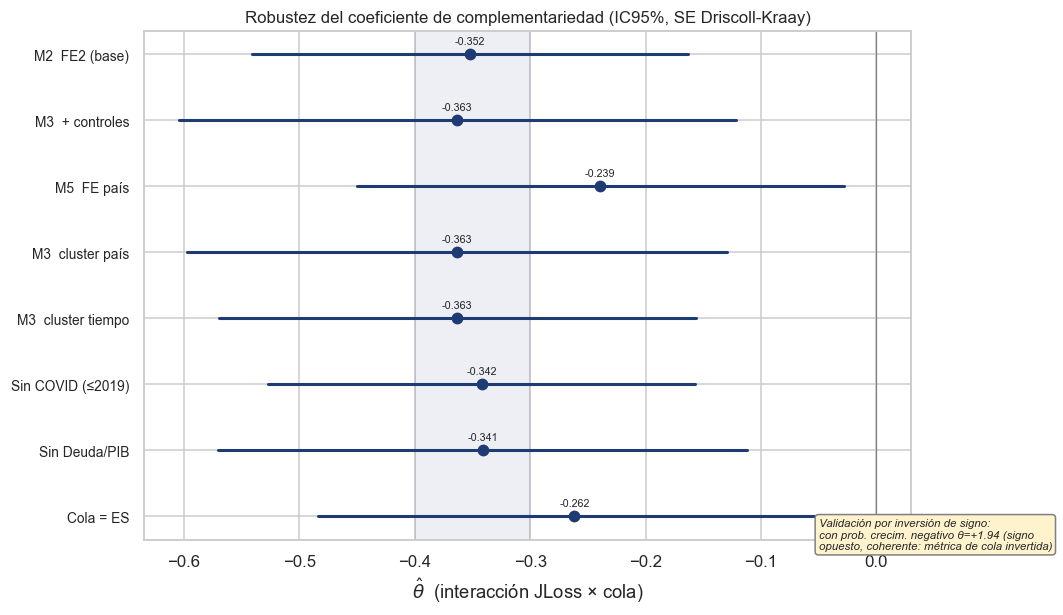

In [31]:
rows = []
def addrow(lbl, est, se): rows.append((lbl, est, est-1.96*se, est+1.96*se))

# M2-M6 y variantes (reestimadas con DK)
m2 = feols('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects')
addrow('M2  FE2 (base)', m2.params['JxG_c'], m2.std_errors['JxG_c'])
addrow('M3  + controles', m3.params['JxG_c'], m3.std_errors['JxG_c'])
m5 = feols(f'EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + VIX + {FC} + EntityEffects')
addrow('M5  FE país', m5.params['JxG_c'], m5.std_errors['JxG_c'])

# variantes de SE sobre M3 (mismo punto, distinta SE)
m3_ce = PanelOLS.from_formula(f'EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + {FC} + EntityEffects + TimeEffects', Pi).fit(cov_type='clustered', cluster_entity=True)
addrow('M3  cluster país', m3_ce.params['JxG_c'], m3_ce.std_errors['JxG_c'])
m3_ct = PanelOLS.from_formula(f'EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + {FC} + EntityEffects + TimeEffects', Pi).fit(cov_type='clustered', cluster_time=True)
addrow('M3  cluster tiempo', m3_ct.params['JxG_c'], m3_ct.std_errors['JxG_c'])

# sin COVID
sub = P[P['quarter'].str[:4].astype(int) < 2020].set_index(['country','t'])
m_nc = PanelOLS.from_formula(f'EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + {FC} + EntityEffects + TimeEffects', sub).fit(**DK)
addrow('Sin COVID (≤2019)', m_nc.params['JxG_c'], m_nc.std_errors['JxG_c'])

# sin deuda
FCnd = ' + '.join([c for c in CTRL if c!='debt_gdp'])
m_nd = feols(f'EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + {FCnd} + EntityEffects + TimeEffects')
addrow('Sin Deuda/PIB', m_nd.params['JxG_c'], m_nd.std_errors['JxG_c'])

# ES
m6 = feols(f'EMBI_bps ~ JLoss_c + ES_pp_c + JxES_c + {FC} + EntityEffects + TimeEffects')
addrow('Cola = ES', m6.params['JxES_c'], m6.std_errors['JxES_c'])

fig, ax = plt.subplots(figsize=(9,6))
ax.axvspan(-0.40,-0.30, color='#1f3b73', alpha=.08)
ax.axvline(0, color='grey', lw=.8)
for i,(lbl,est,l,h) in enumerate(rows):
    ax.plot([l,h],[i,i], color='#1f3b73', lw=2)
    ax.scatter([est],[i], color='#1f3b73', zorder=5, s=45)
    ax.annotate(f'{est:+.3f}', (est,i), textcoords='offset points', xytext=(0,7),
                ha='center', fontsize=7)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows], fontsize=9)
ax.set_xlabel(r'$\hat\theta$  (interacción JLoss × cola)')
ax.set_title('Robustez del coeficiente de complementariedad (IC95%, SE Driscoll-Kraay)')
ax.invert_yaxis()
# anotación prob_neg (inversión de signo, escala distinta)
m_pn = feols(f'EMBI_bps ~ JLoss_c + I(prob_neg-prob_neg.mean()) + I(JLoss_c*(prob_neg-prob_neg.mean())) + {FC} + EntityEffects + TimeEffects')
ax.text(-0.05, len(rows)-0.5,
        'Validación por inversión de signo:\ncon prob. crecim. negativo θ=+1.94 (signo\nopuesto, coherente: métrica de cola invertida)',
        fontsize=7.5, style='italic',
        bbox=dict(boxstyle='round', fc='#fff3cd', ec='grey'))
savefig('14_forest_theta'); plt.show()

## 14.5 Modelo de umbral de Hansen (Sección 4.3.3)

Modelo de umbral con efectos fijos (Hansen, 1999/2000): el efecto de $JLoss$ sobre el
spread cambia de régimen según un umbral $\gamma$ del GaR. Panel izquierdo: perfil del
estadístico $LR(\gamma)$; el umbral estimado $\hat\gamma$ minimiza la suma de
cuadrados y el IC95% se obtiene por inversión del estadístico ($LR\le 7.35$, valor
crítico de Hansen 2000). Panel derecho: efecto de $JLoss$ en cada régimen.

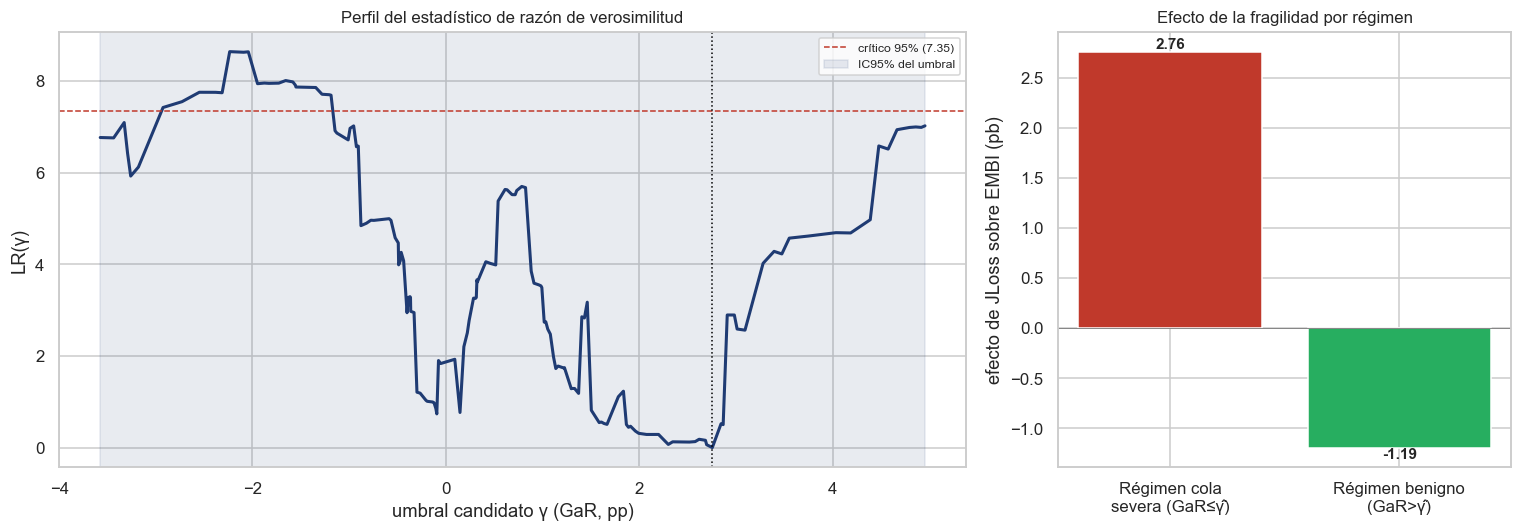

Umbral estimado γ̂ = 2.755 pp  (IC95%: [-3.57, 4.95])
Efecto JLoss régimen severo = 2.759 pb | régimen benigno = -1.193 pb


In [32]:
# within-transform por país (efectos fijos, Hansen 1999 es one-way)
g = P['country']
def wc(s): return (s - s.groupby(g.values).transform('mean')).values
yw = wc(P['EMBI_bps']); Jw = wc(P['JLoss']); Gw = wc(P['GaR_pp']); Rw = wc(P['reer'])
q  = P['GaR_pp'].values
n  = len(yw)

def ssr_beta(gam):
    dlo = (q <= gam).astype(float)
    X = np.column_stack([Jw*dlo, Jw*(1-dlo), Gw, Rw])
    beta, *_ = np.linalg.lstsq(X, yw, rcond=None)
    e = yw - X@beta
    return float(e@e), beta

grid = np.quantile(q, np.linspace(.10,.90,150))
res  = [ssr_beta(gm) for gm in grid]
ssrs = np.array([r[0] for r in res])
ihat = ssrs.argmin(); gam_hat = grid[ihat]; ssr_min = ssrs[ihat]
sig2 = ssr_min/n
LR   = (ssrs - ssr_min)/sig2
crit = 7.35
inside = grid[LR <= crit]
ci_lo, ci_hi = inside.min(), inside.max()
beta_lo, beta_hi = res[ihat][1][0], res[ihat][1][1]

fig, axes = plt.subplots(1,2, figsize=(14,5), gridspec_kw={'width_ratios':[2,1]})
axes[0].plot(grid, LR, color='#1f3b73', lw=2)
axes[0].axhline(crit, color='#c0392b', ls='--', lw=1, label='crítico 95% (7.35)')
axes[0].axvline(gam_hat, color='black', ls=':', lw=1)
axes[0].axvspan(ci_lo, ci_hi, color='#1f3b73', alpha=.10, label='IC95% del umbral')
axes[0].annotate(f'γ̂ = {gam_hat:.2f} pp', (gam_hat, crit*1.4), fontsize=9)
axes[0].set_xlabel('umbral candidato γ (GaR, pp)'); axes[0].set_ylabel('LR(γ)')
axes[0].set_title('Perfil del estadístico de razón de verosimilitud'); axes[0].legend(fontsize=8)

axes[1].bar(['Régimen cola\nsevera (GaR≤γ̂)','Régimen benigno\n(GaR>γ̂)'],
            [beta_lo, beta_hi], color=['#c0392b','#27ae60'])
axes[1].axhline(0, color='grey', lw=.6)
for i,v in enumerate([beta_lo,beta_hi]):
    axes[1].annotate(f'{v:.2f}', (i,v), ha='center',
                     va='bottom' if v>=0 else 'top', fontsize=10, fontweight='bold')
axes[1].set_ylabel('efecto de JLoss sobre EMBI (pb)')
axes[1].set_title('Efecto de la fragilidad por régimen')
plt.tight_layout(); savefig('14_umbral_hansen'); plt.show()
print(f'Umbral estimado γ̂ = {gam_hat:.3f} pp  (IC95%: [{ci_lo:.2f}, {ci_hi:.2f}])')
print(f'Efecto JLoss régimen severo = {beta_lo:.3f} pb | régimen benigno = {beta_hi:.3f} pb')

## 14.6 Series de tiempo por país: JLoss, GaR y EMBI

JLoss y GaR (ejes gemelos) con EMBI superpuesto, sombreando episodios de estrés
(*commodities* 2015–16, COVID 2020). Muestra dónde coinciden alta fragilidad y cola
severa.

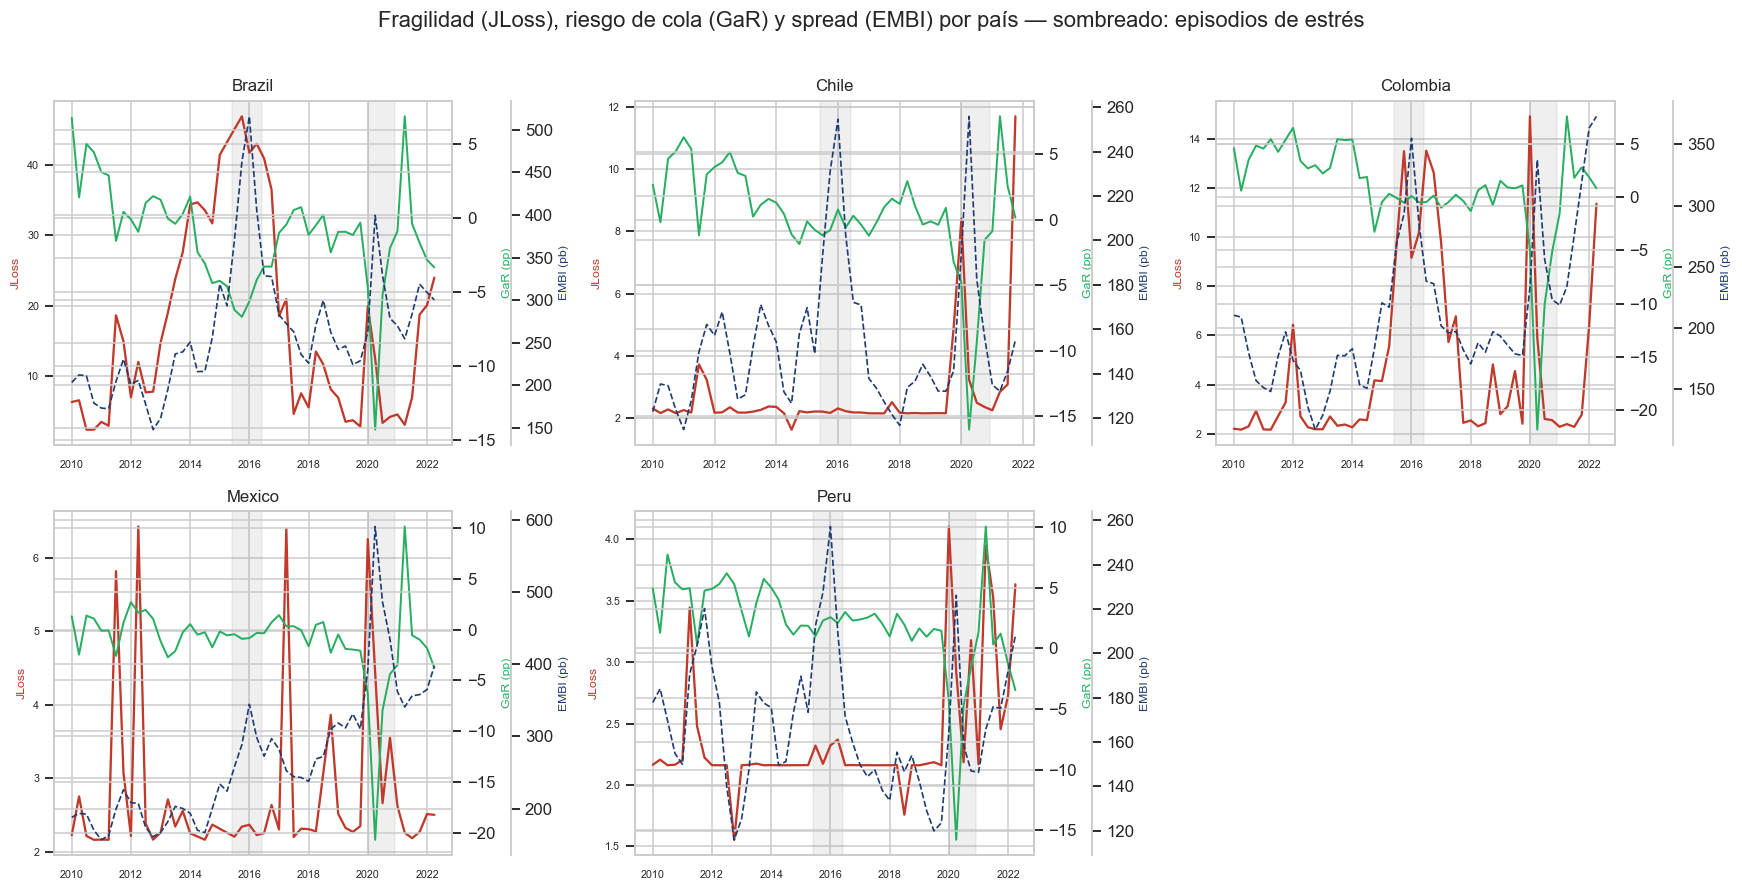

In [33]:
fig, axes = plt.subplots(2,3, figsize=(16,8)); axes=axes.ravel()
for i,(c,gg) in enumerate(P.groupby('country')):
    gg=gg.sort_values('date'); ax=axes[i]
    ax.plot(gg['date'], gg['JLoss'], color='#c0392b', lw=1.5, label='JLoss')
    ax.set_ylabel('JLoss', color='#c0392b', fontsize=8)
    a2=ax.twinx(); a2.plot(gg['date'], gg['GaR_pp'], color='#27ae60', lw=1.3, label='GaR (pp)')
    a2.set_ylabel('GaR (pp)', color='#27ae60', fontsize=8)
    a3=ax.twinx(); a3.spines['right'].set_position(('outward',38))
    a3.plot(gg['date'], gg['EMBI_bps'], color='#1f3b73', lw=1.1, ls='--', label='EMBI')
    a3.set_ylabel('EMBI (pb)', color='#1f3b73', fontsize=8)
    for (s,e) in [('2015-06','2016-06'),('2020-01','2020-12')]:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color='grey', alpha=.12)
    ax.set_title(c.capitalize()); ax.tick_params(labelsize=7)
axes[-1].axis('off')
fig.suptitle('Fragilidad (JLoss), riesgo de cola (GaR) y spread (EMBI) por país — sombreado: episodios de estrés', y=1.01)
plt.tight_layout(); savefig('14_series_pais'); plt.show()

## 14.7 Contabilidad del spread en un episodio

Descomposición del cambio predicho del spread en aportes de JLoss, GaR y el término de
interacción, para el shock COVID (2019Q4→2020Q2). Cuantifica qué fracción del salto fue
**amplificación** (interacción).

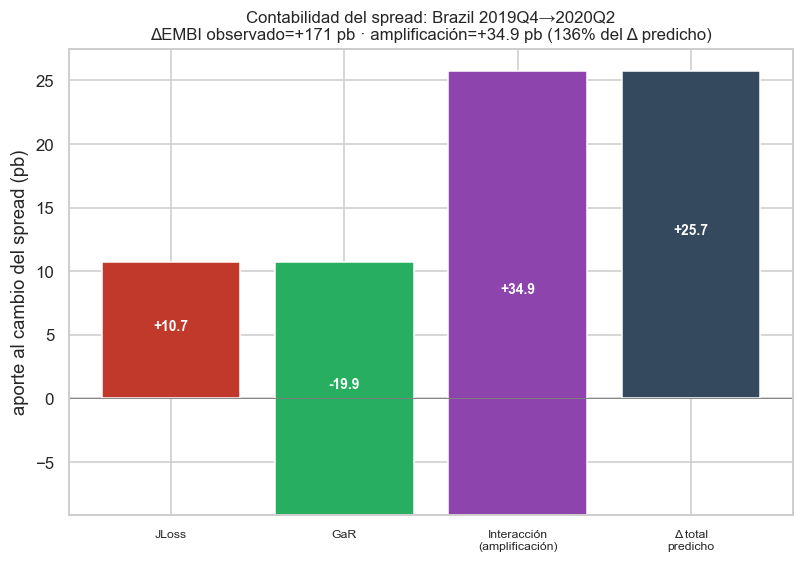

In [34]:
def episode_decomp(country, q0, q1):
    a = P[(P.country==country)&(P.quarter==q0)].iloc[0]
    b = P[(P.country==country)&(P.quarter==q1)].iloc[0]
    dJ = (b['JLoss_c']-a['JLoss_c']); dG = (b['GaR_pp_c']-a['GaR_pp_c'])
    dInt = (b['JLoss_c']*b['GaR_pp_c'] - a['JLoss_c']*a['GaR_pp_c'])
    comp = {'JLoss': b1*dJ, 'GaR': b2*dG, 'Interacción\n(amplificación)': th*dInt}
    return comp, (b['EMBI_bps']-a['EMBI_bps'])

country, q0, q1 = 'brazil', '2019Q4', '2020Q2'
comp, dEMBI_obs = episode_decomp(country, q0, q1)

fig, ax = plt.subplots(figsize=(8.5,5.5))
labels=list(comp); vals=list(comp.values())
cum=np.cumsum([0]+vals[:-1]); colors=['#c0392b','#27ae60','#8e44ad']
for i,(l,v) in enumerate(zip(labels,vals)):
    ax.bar(i, v, bottom=cum[i], color=colors[i])
    ax.annotate(f'{v:+.1f}', (i, cum[i]+v/2), ha='center', fontsize=9, fontweight='bold', color='white')
ax.bar(len(labels), sum(vals), color='#34495e', label='Δ predicho total')
ax.annotate(f'{sum(vals):+.1f}', (len(labels), sum(vals)/2), ha='center', fontsize=9, fontweight='bold', color='white')
ax.set_xticks(range(len(labels)+1)); ax.set_xticklabels(labels+['Δ total\npredicho'], fontsize=8)
ax.axhline(0, color='grey', lw=.6)
ax.set_ylabel('aporte al cambio del spread (pb)')
share = th*( P[(P.country==country)&(P.quarter==q1)].iloc[0]['JLoss_c']*P[(P.country==country)&(P.quarter==q1)].iloc[0]['GaR_pp_c'] - P[(P.country==country)&(P.quarter==q0)].iloc[0]['JLoss_c']*P[(P.country==country)&(P.quarter==q0)].iloc[0]['GaR_pp_c'])
ax.set_title(f'Contabilidad del spread: {country.capitalize()} {q0}→{q1}\n'
             f'ΔEMBI observado={dEMBI_obs:+.0f} pb · amplificación={share:+.1f} pb ({share/sum(vals)*100:.0f}% del Δ predicho)')
savefig('14_contabilidad_episodio'); plt.show()

## 14.8 Contrafactual "sin *doom loop*" (θ = 0)

La prima de amplificación atribuible a la complementariedad es el aporte del término de
interacción al spread predicho, $\hat\theta\cdot(JLoss_c\times GaR_c)$. Se grafica por
país en el tiempo: la brecha se concentra en los picos de estrés —consistente con la
lectura de la especificación logarítmica (M4).

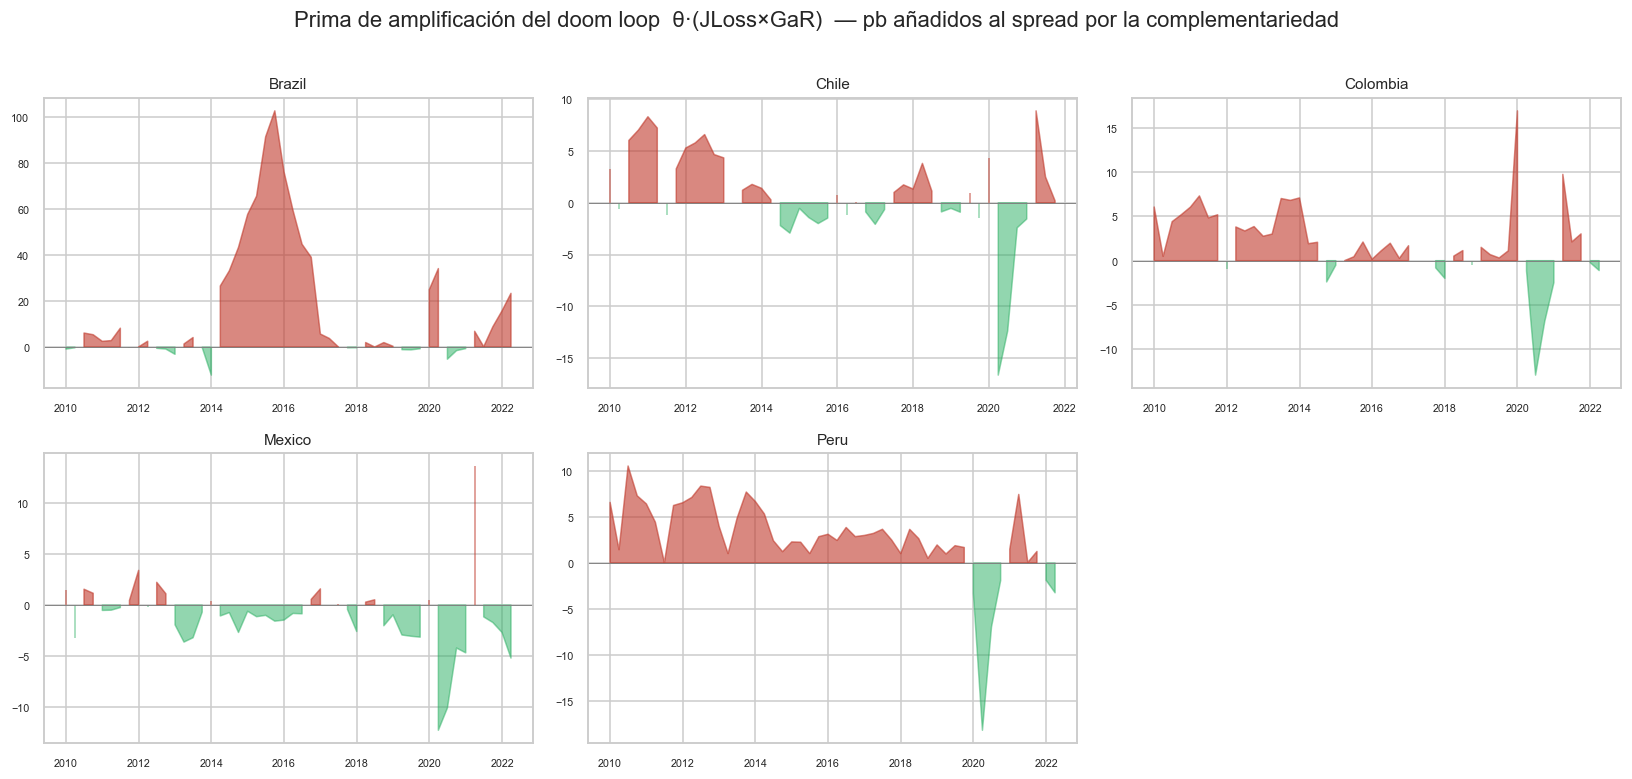

Prima de amplificación media donde es positiva: 7.75 pb · máx 102.8 pb


In [35]:
P['amp_premium'] = th * P['JLoss_c'] * P['GaR_pp_c']   # gap full vs theta=0
fig, axes = plt.subplots(2,3, figsize=(15,7)); axes=axes.ravel()
for i,(c,gg) in enumerate(P.groupby('country')):
    gg=gg.sort_values('date'); ax=axes[i]
    ax.fill_between(gg['date'], 0, gg['amp_premium'],
                    where=gg['amp_premium']>=0, color='#c0392b', alpha=.6)
    ax.fill_between(gg['date'], 0, gg['amp_premium'],
                    where=gg['amp_premium']<0, color='#27ae60', alpha=.5)
    ax.axhline(0, color='grey', lw=.6); ax.set_title(c.capitalize(), fontsize=10)
    ax.tick_params(labelsize=7)
axes[-1].axis('off')
fig.suptitle('Prima de amplificación del doom loop  θ·(JLoss×GaR)  — pb añadidos al spread por la complementariedad', y=1.01)
plt.tight_layout(); savefig('14_contrafactual'); plt.show()
print('Prima de amplificación media donde es positiva: '
      f"{P.loc[P['amp_premium']>0,'amp_premium'].mean():.2f} pb · máx {P['amp_premium'].max():.1f} pb")

## 14.9 Heterogeneidad *leave-one-country-out*

Con solo cinco *clusters*, la preocupación más previsible del comité es que un país
arrastre el resultado. Se reestima θ (M2, FE bidireccional) excluyendo cada país.

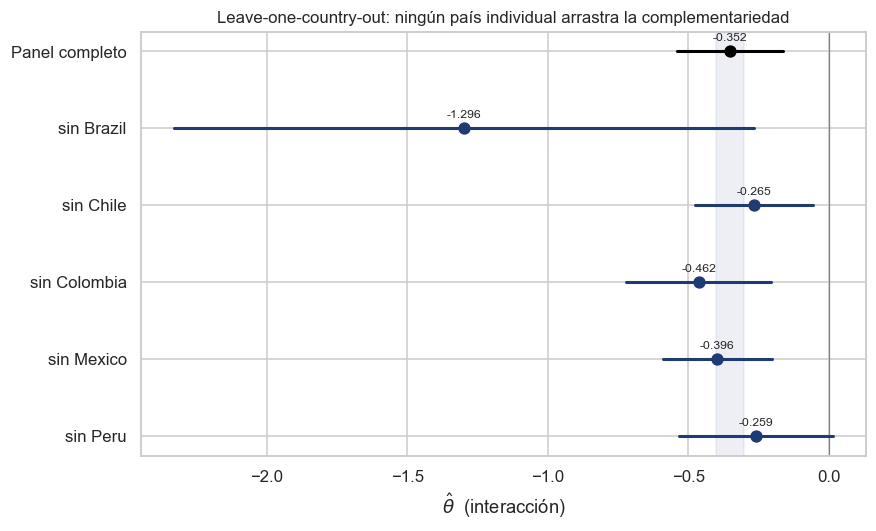

In [36]:
rows=[]
full = feols('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects')
rows.append(('Panel completo', full.params['JxG_c'], full.std_errors['JxG_c']))
for c in sorted(P['country'].unique()):
    sub = P[P.country!=c].set_index(['country','t'])
    r = PanelOLS.from_formula('EMBI_bps ~ JLoss_c + GaR_pp_c + JxG_c + EntityEffects + TimeEffects', sub).fit(**DK)
    rows.append((f'sin {c.capitalize()}', r.params['JxG_c'], r.std_errors['JxG_c']))

fig, ax = plt.subplots(figsize=(8.5,5))
ax.axvline(0, color='grey', lw=.8)
ax.axvspan(full.params['JxG_c']-0.05, full.params['JxG_c']+0.05, color='#1f3b73', alpha=.08)
for i,(lbl,est,se) in enumerate(rows):
    col = 'black' if lbl=='Panel completo' else '#1f3b73'
    ax.plot([est-1.96*se, est+1.96*se],[i,i], color=col, lw=2)
    ax.scatter([est],[i], color=col, s=50, zorder=5)
    ax.annotate(f'{est:+.3f}', (est,i), textcoords='offset points', xytext=(0,7), ha='center', fontsize=8)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows])
ax.set_xlabel(r'$\hat\theta$  (interacción)'); ax.invert_yaxis()
ax.set_title('Leave-one-country-out: ningún país individual arrastra la complementariedad')
savefig('14_leave_one_out'); plt.show()